# PROD-1. Деплой и интеграция

## 1. Введение

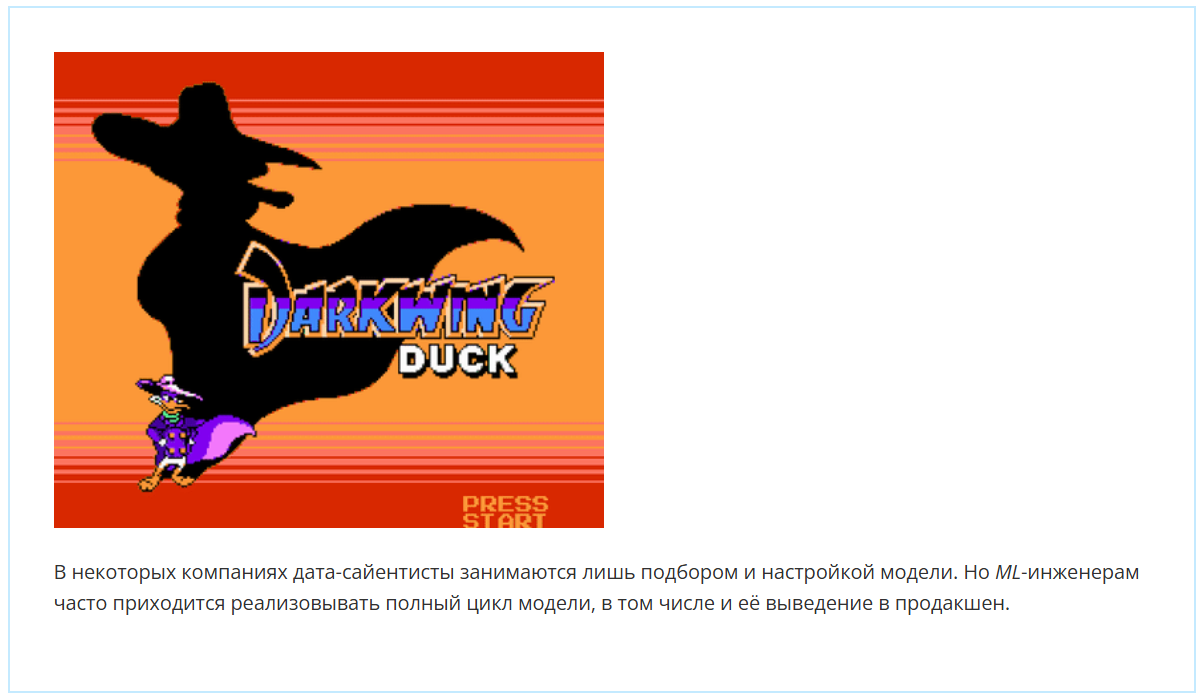

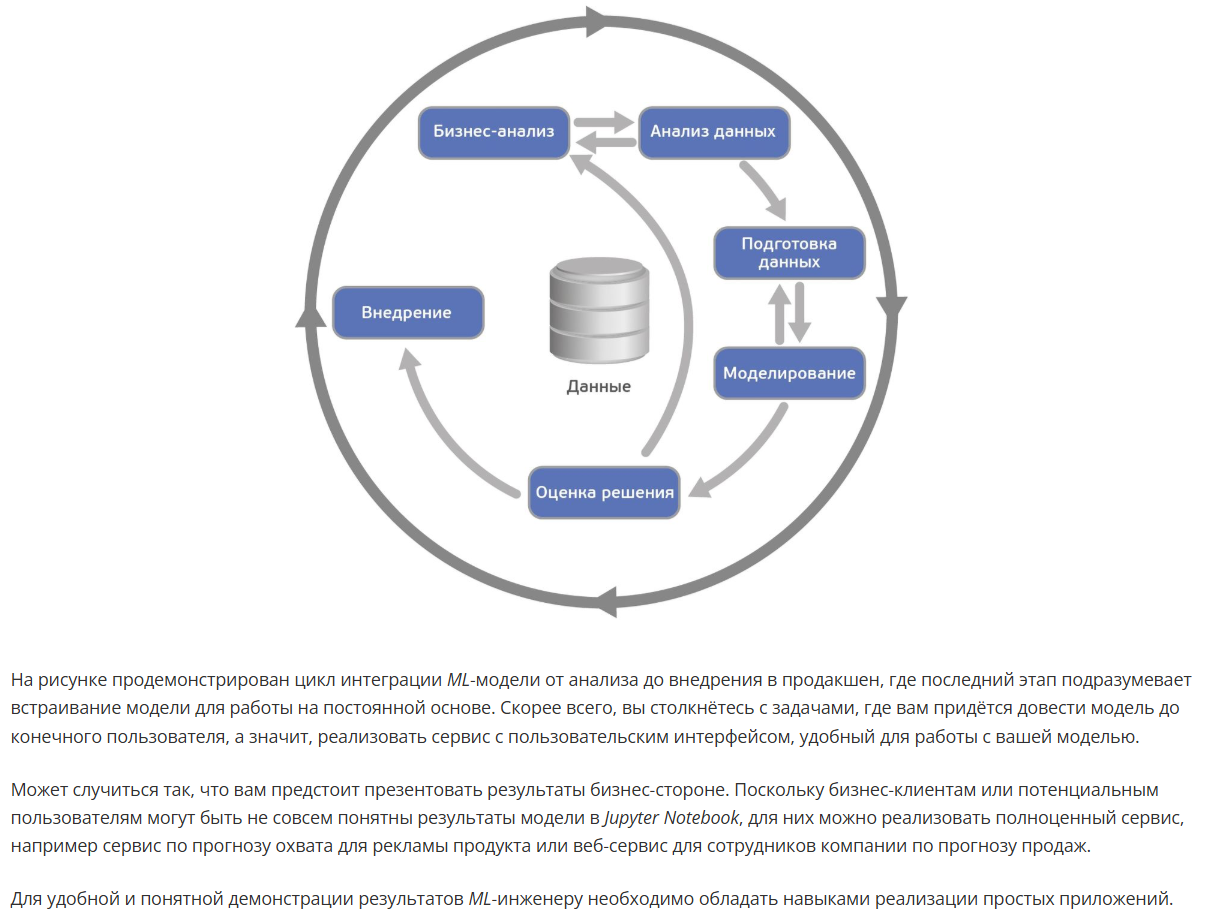

## 2. Протокол HTTP. Recap

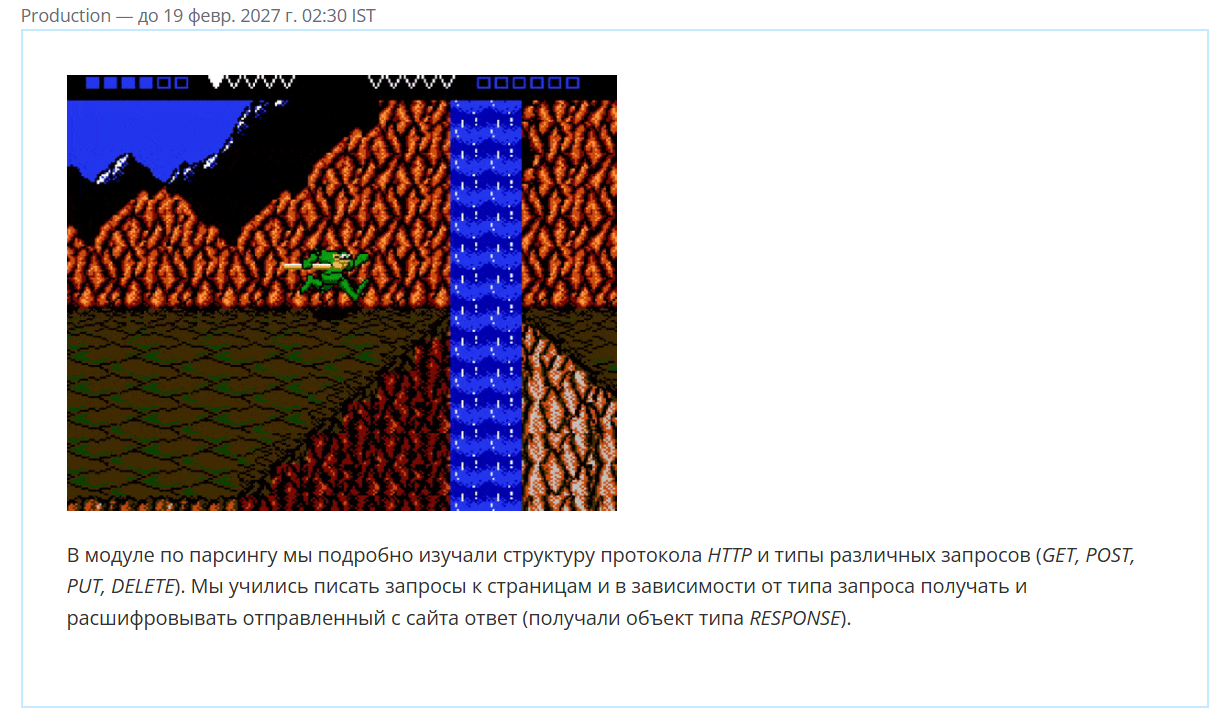

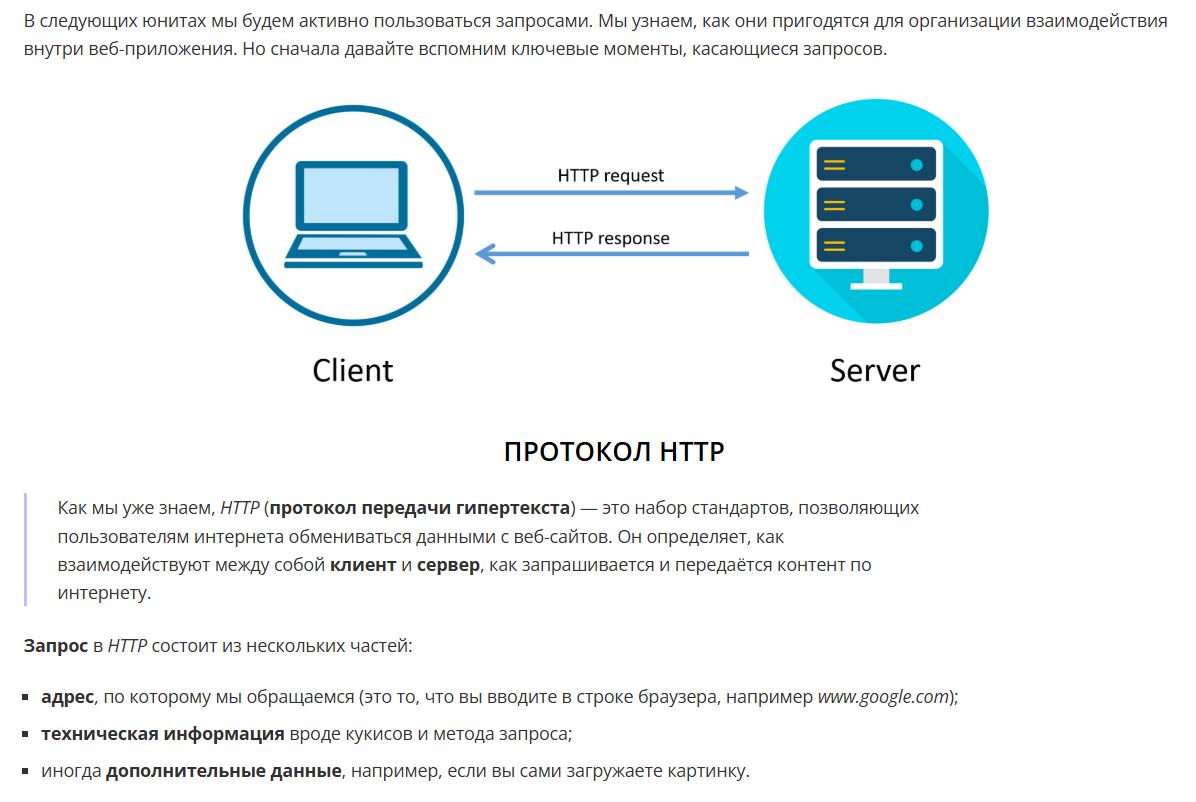

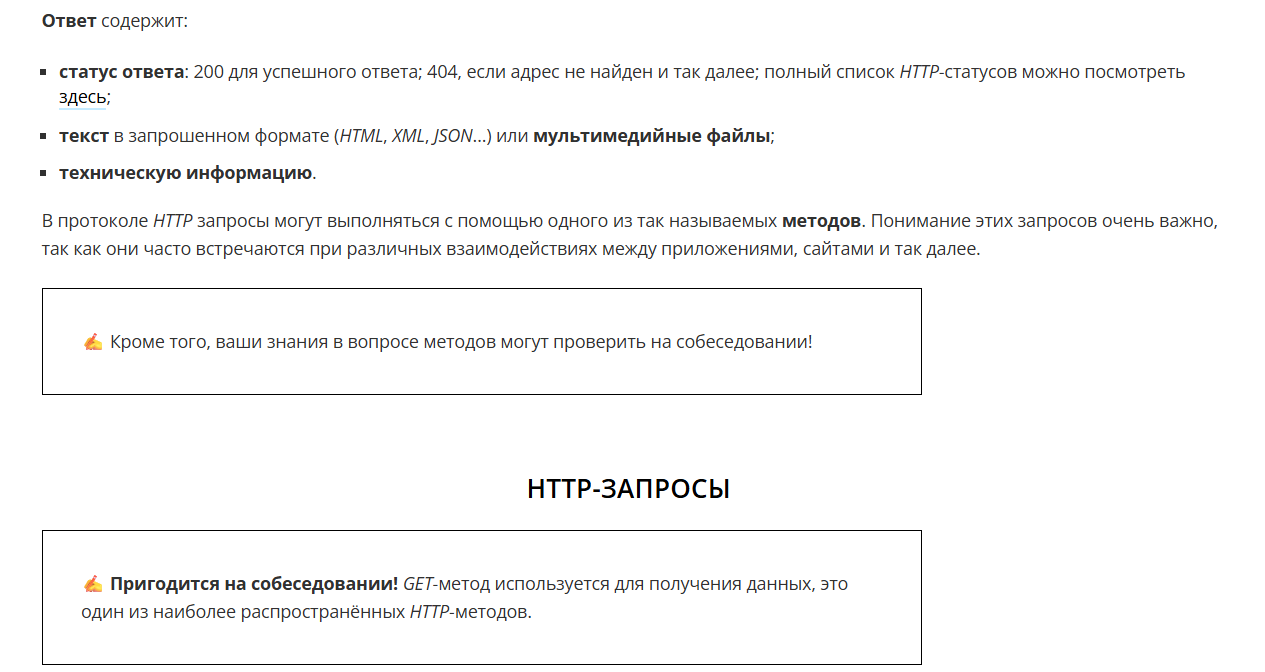

https://ru.wikipedia.org/wiki/Список_кодов_состояния_HTTP

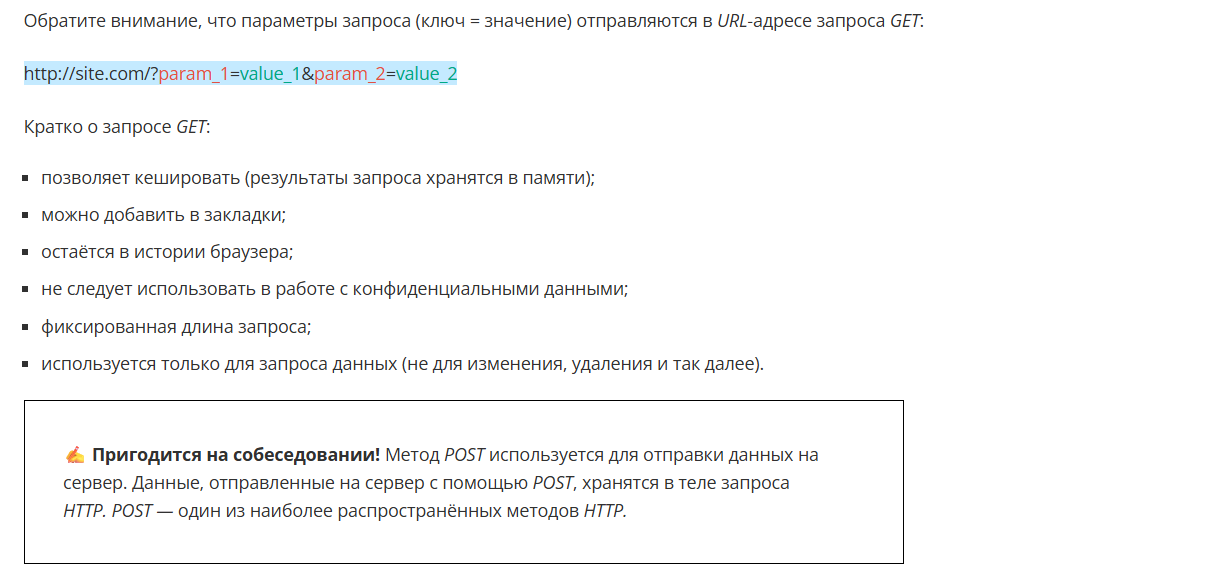

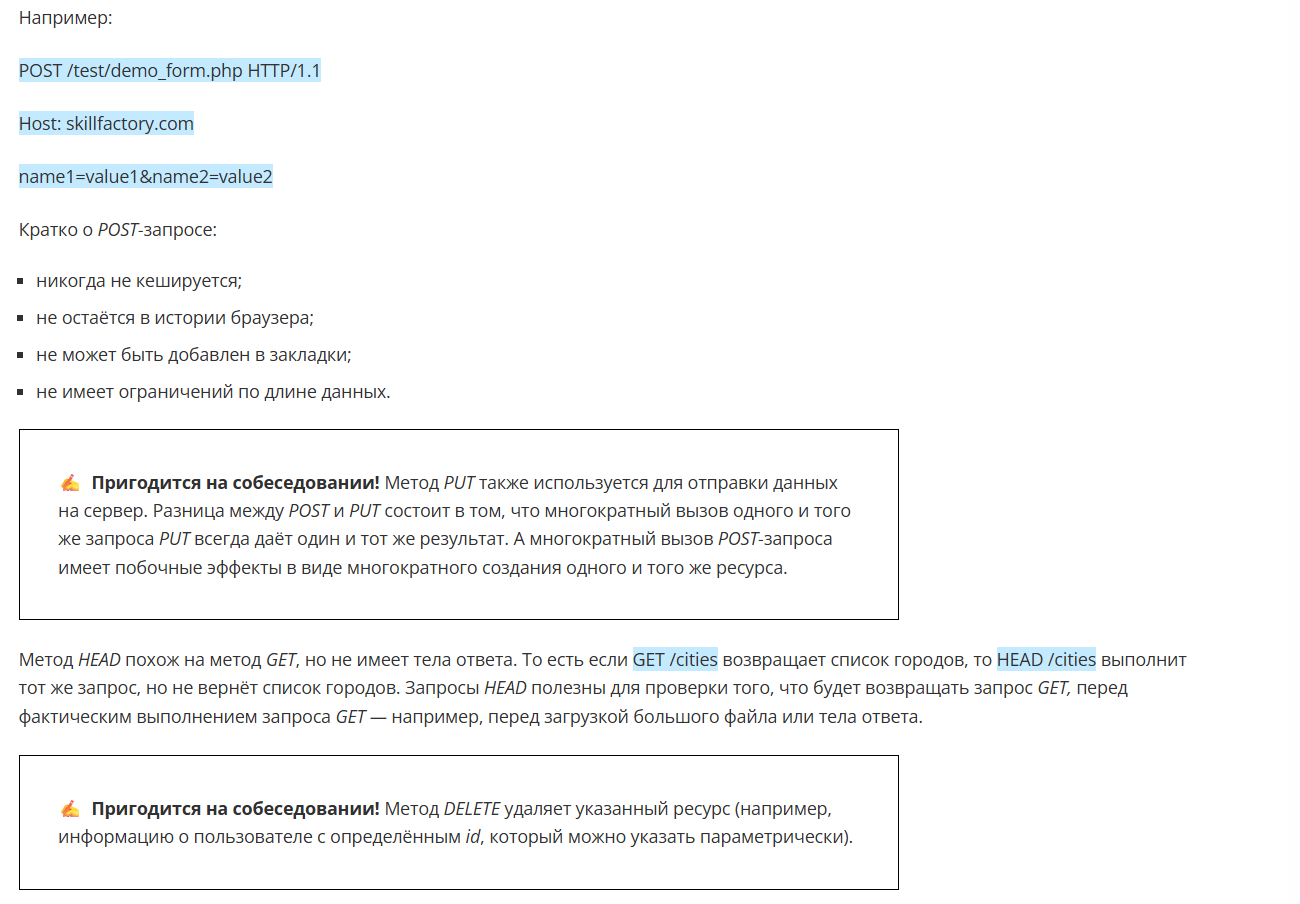

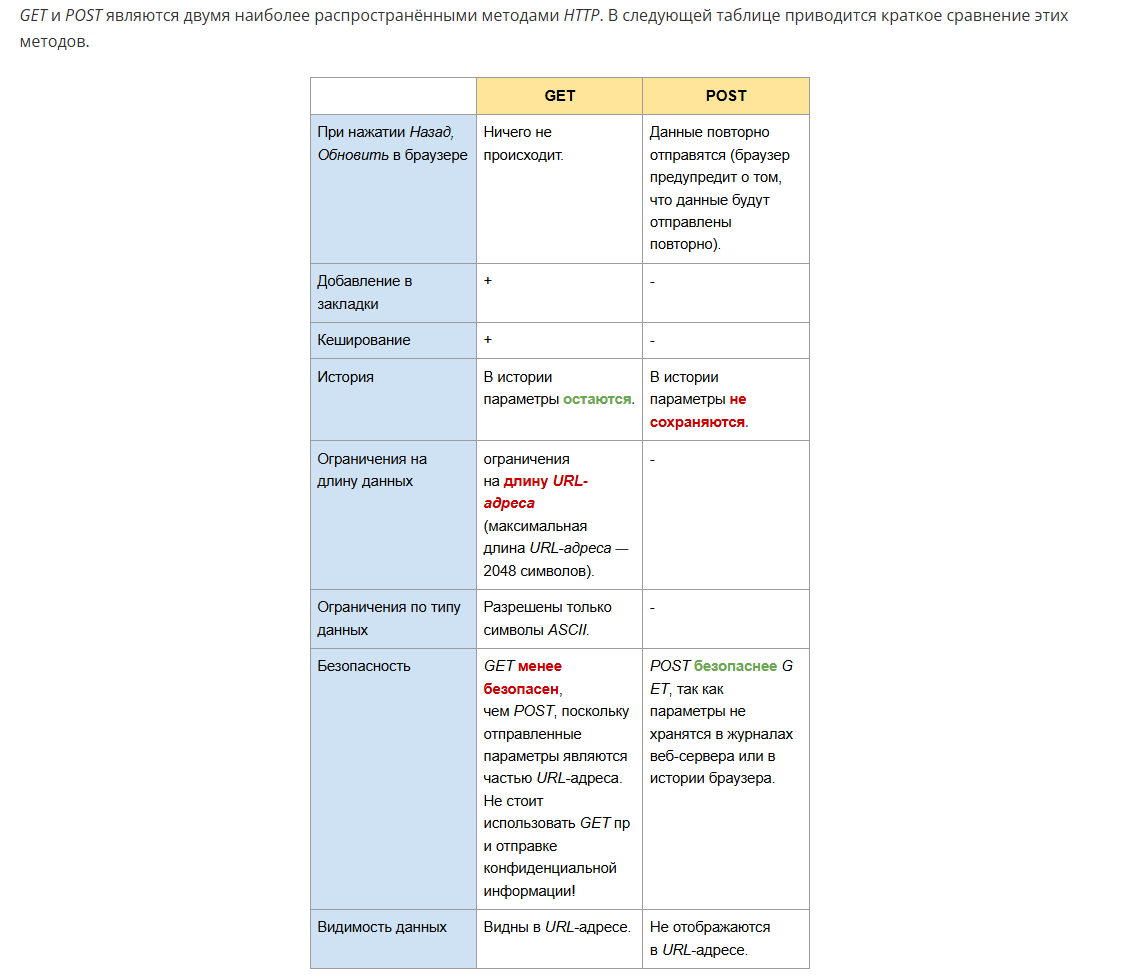

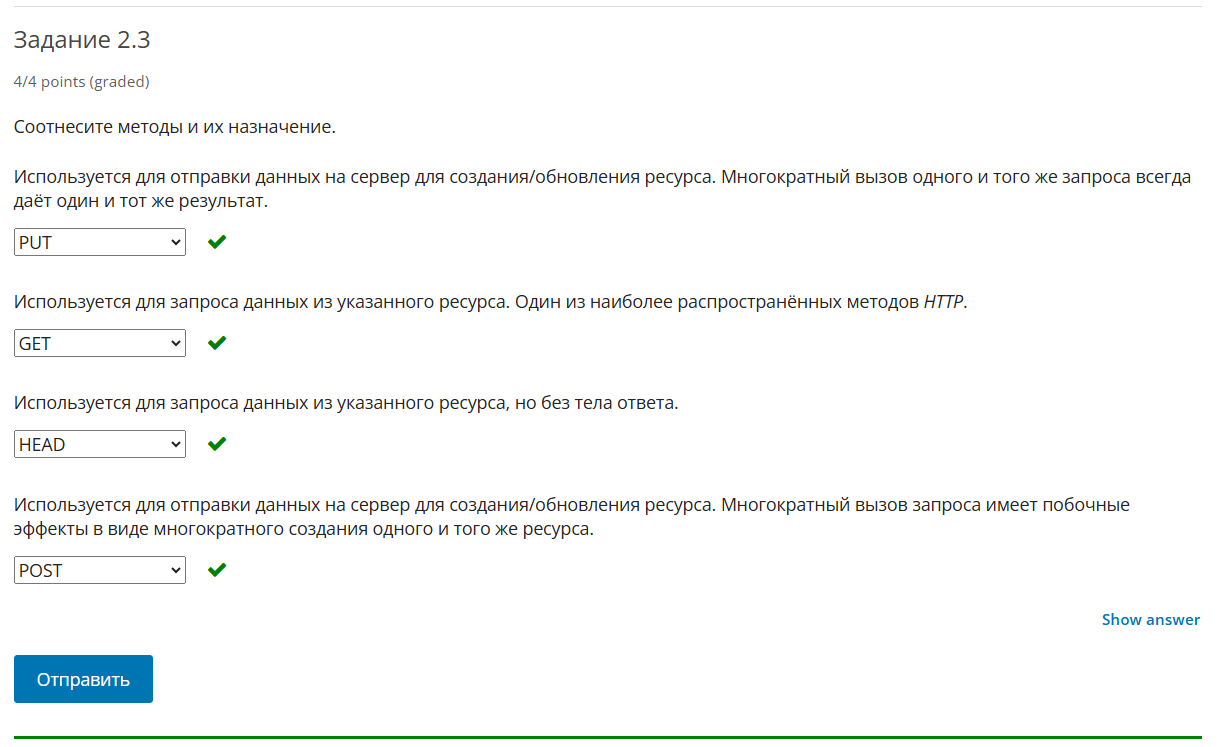

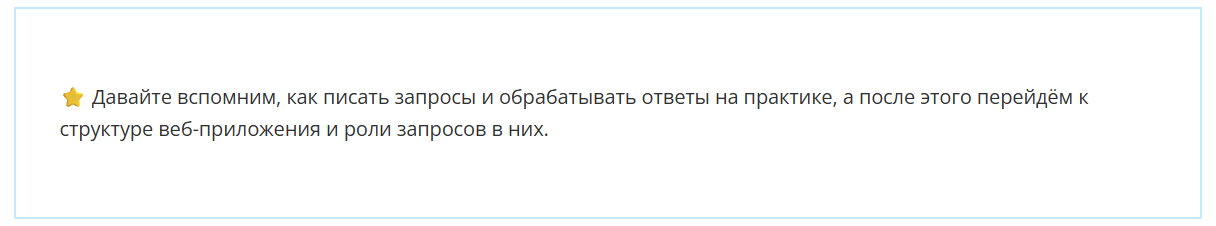

# 3. Протокол HTTP. Практика

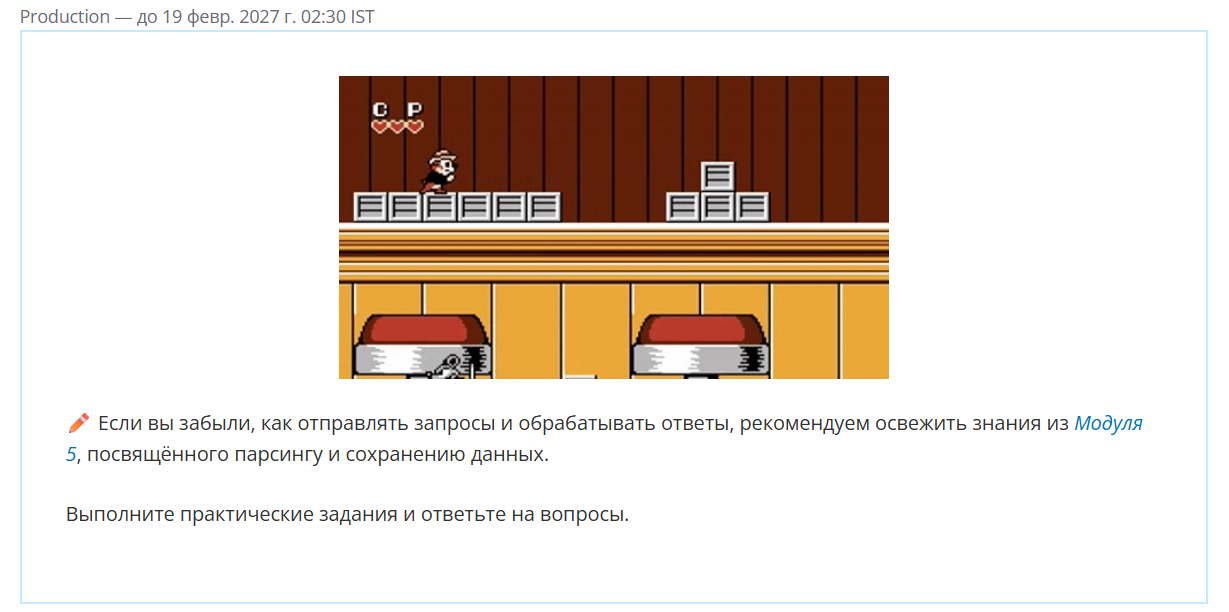

https://apps.skillfactory.ru/learning/course/course-v1:SkillFactory+DSPRML+ALWAYS/block-v1:SkillFactory+DSPRML+ALWAYS+type@sequential+block@93c6d591b64345cda5f147cd781465c1/block-v1:SkillFactory+DSPRML+ALWAYS+type@vertical+block@ea3c7b85feb94b778219e69cbe8bd2d8

### Задание 3.5
 
Отправим данные:

data = """{'test': 'cheers'}"""
…в POST-запросе на страницу "http://httpbin.org/post" .

Какой ключ НЕ будет присутствовать в ответе сервера?

In [2]:
import requests

url = "http://httpbin.org/post"
data = """{'test': 'cheers'}"""

response = requests.post(url, data=data)
result = response.json()

print("Ключи ответа:", sorted(result))
print("Ключ 'test' присутствует:", "test" in result)
print("Ответ: ключ 'test' отсутствует; отправленные данные находятся в ключе 'data'.")

Ключи ответа: ['args', 'data', 'files', 'form', 'headers', 'json', 'origin', 'url']
Ключ 'test' присутствует: False
Ответ: ключ 'test' отсутствует; отправленные данные находятся в ключе 'data'.


### Задание 3.6
 
Отправьте PUT-запрос на 'https://httpbin.org/put' с параметром data = {'name':'skillFactory student'}. Вызовите .json() у response (объекта результата запроса). Какое значение у атрибута 'Content-Length'?

In [4]:
import requests

response = requests.put(
    "https://httpbin.org/put",
    data={"name": "skillFactory student"},
    verify=False,
)
result = response.json()

print("Ключи ответа:", sorted(result))
print("Content-Length:", result["headers"]["Content-Length"])

c:\Users\tgorbunov\AppData\Local\Programs\Python\Python310\lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'httpbin.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Ключи ответа: ['args', 'data', 'files', 'form', 'headers', 'json', 'origin', 'url']
Content-Length: 25


### Задание 3.7
 
Удалите добавленные данные с помощью запроса DELETE к ресурсу 'https://httpbin.org/delete'. В качестве параметров передайте ключ и значение для удаления (в виде data={'name':'skillFactory student'}). Напишите и отправьте запрос, проверьте код ответа и выберите правильный вариант из списка.

In [5]:
import requests

response = requests.delete(
    "https://httpbin.org/delete",
    data={"name": "skillFactory student"},
    verify=False,
)
result = response.json()

print("Код ответа:", response.status_code)
print("Удаляемые данные:", result["form"])

c:\Users\tgorbunov\AppData\Local\Programs\Python\Python310\lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'httpbin.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Код ответа: 200
Удаляемые данные: {'name': 'skillFactory student'}


# 4. Микросервисная архитектура

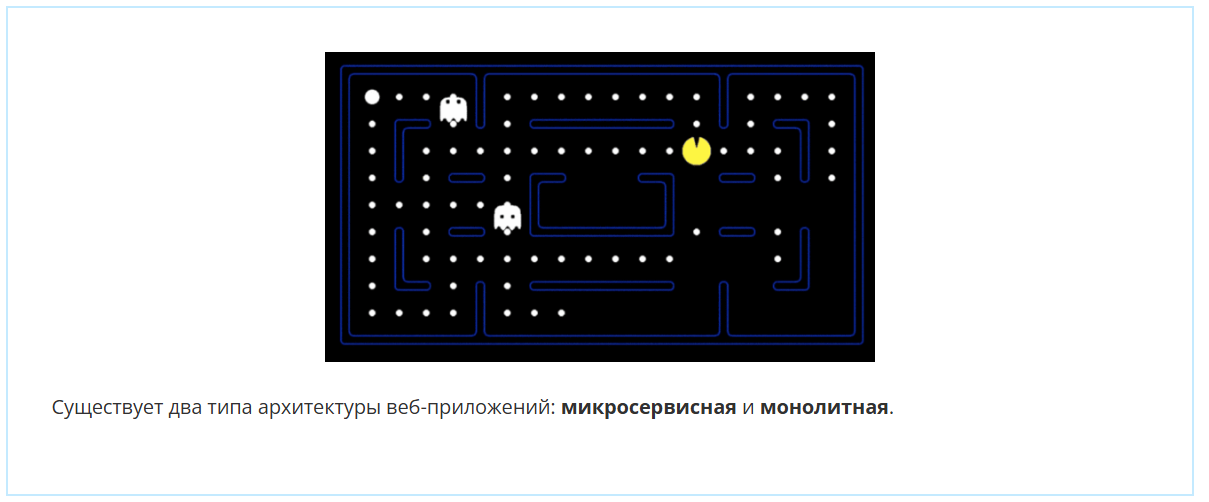

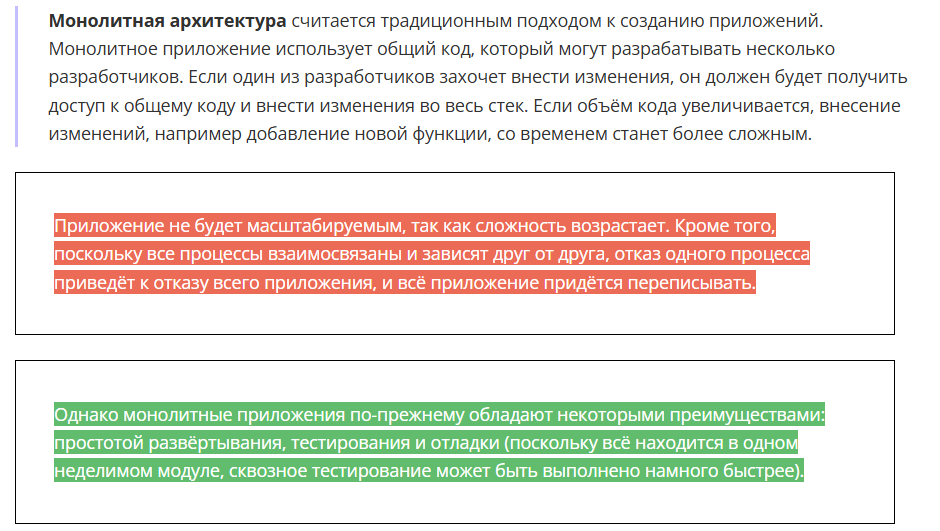

## Что же такое микросервисная архитектура?

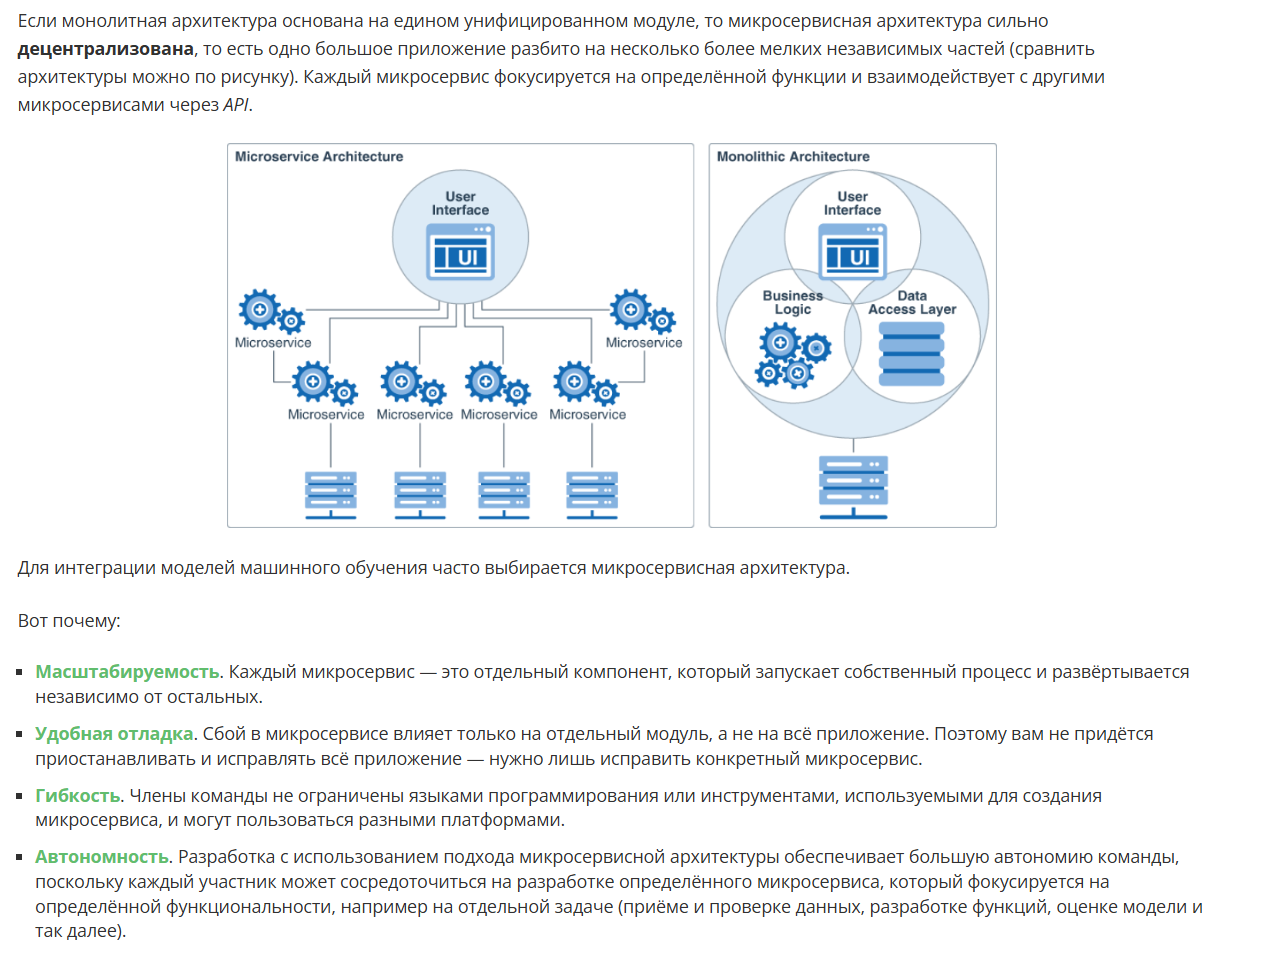

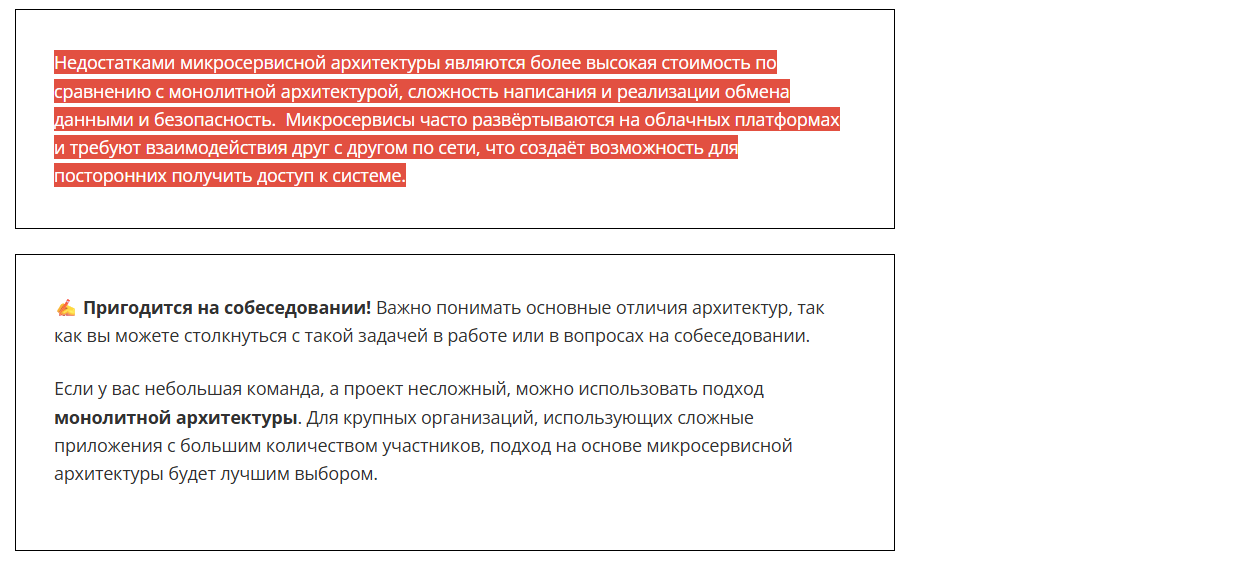

## API (Интерфейс прикладного программирования)

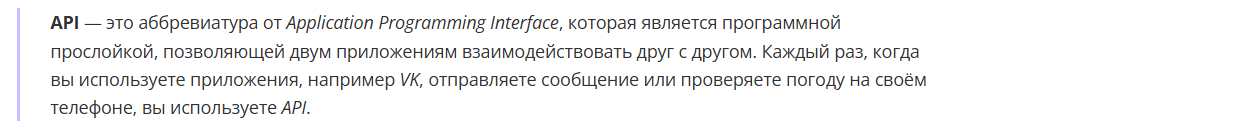

## Rest API

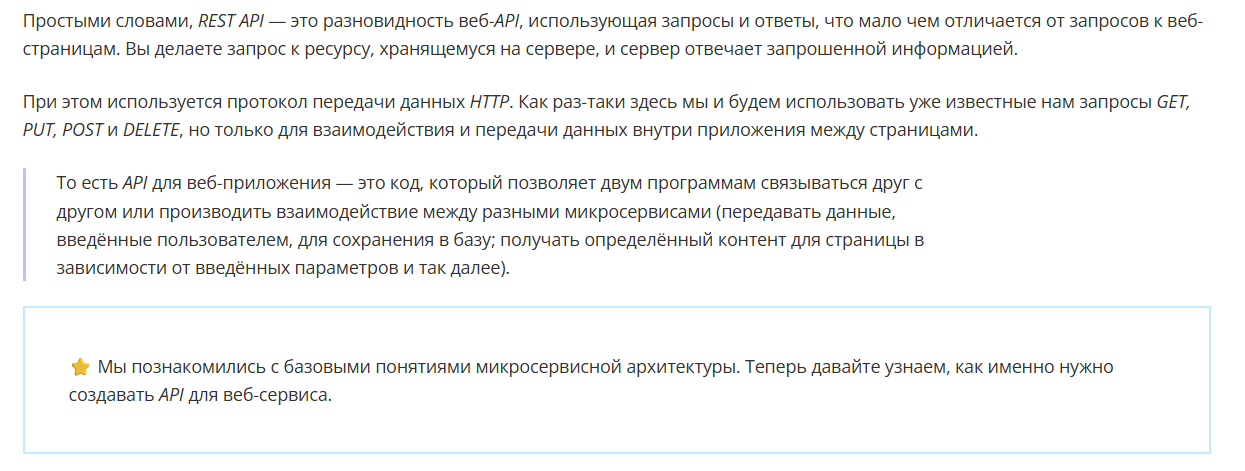

# 5. Создание API веб-сервиса

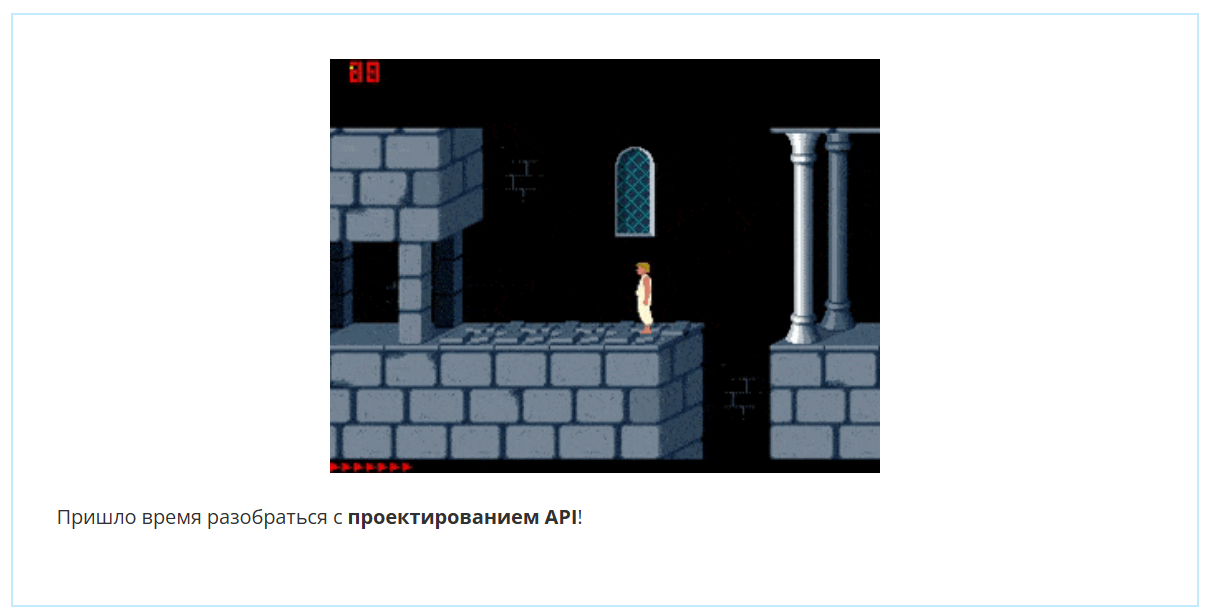

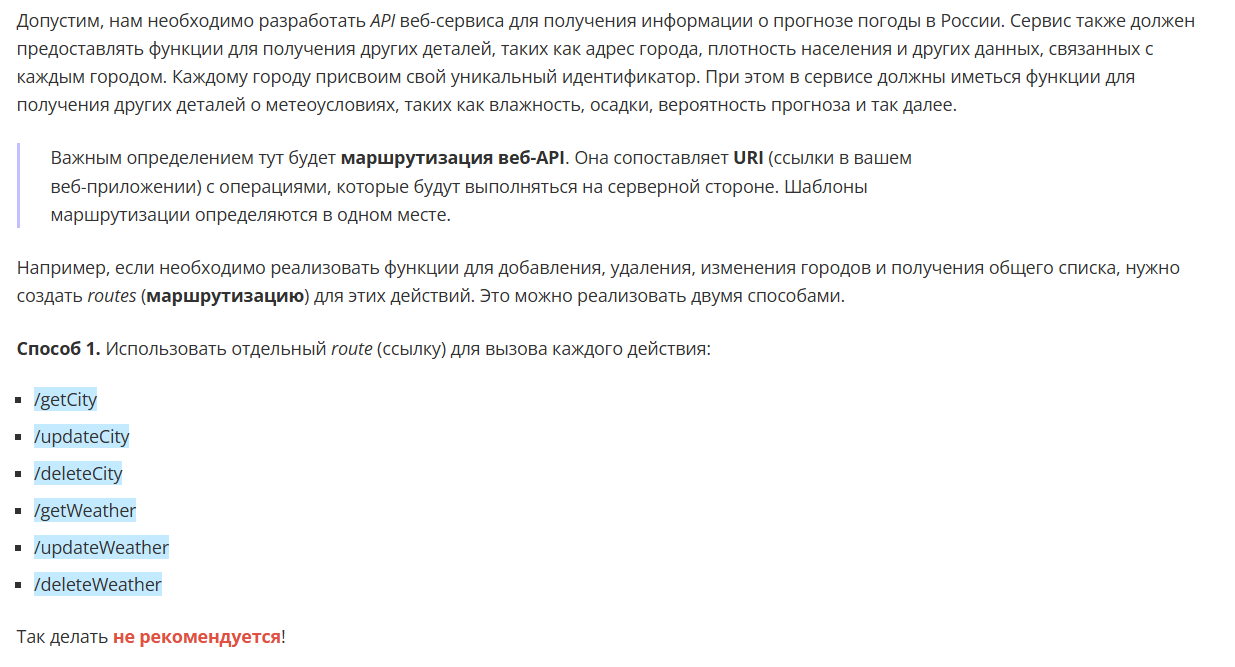

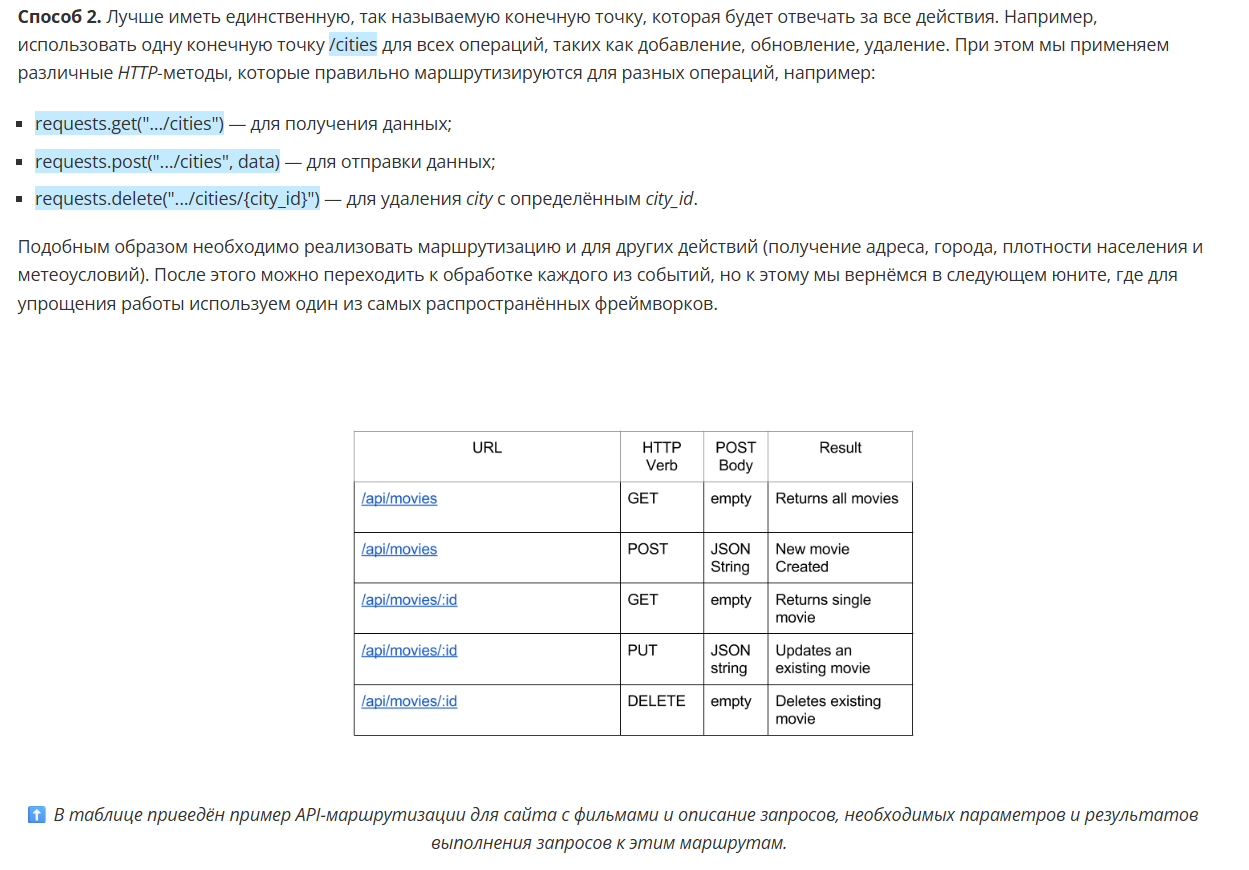

## Документирование API

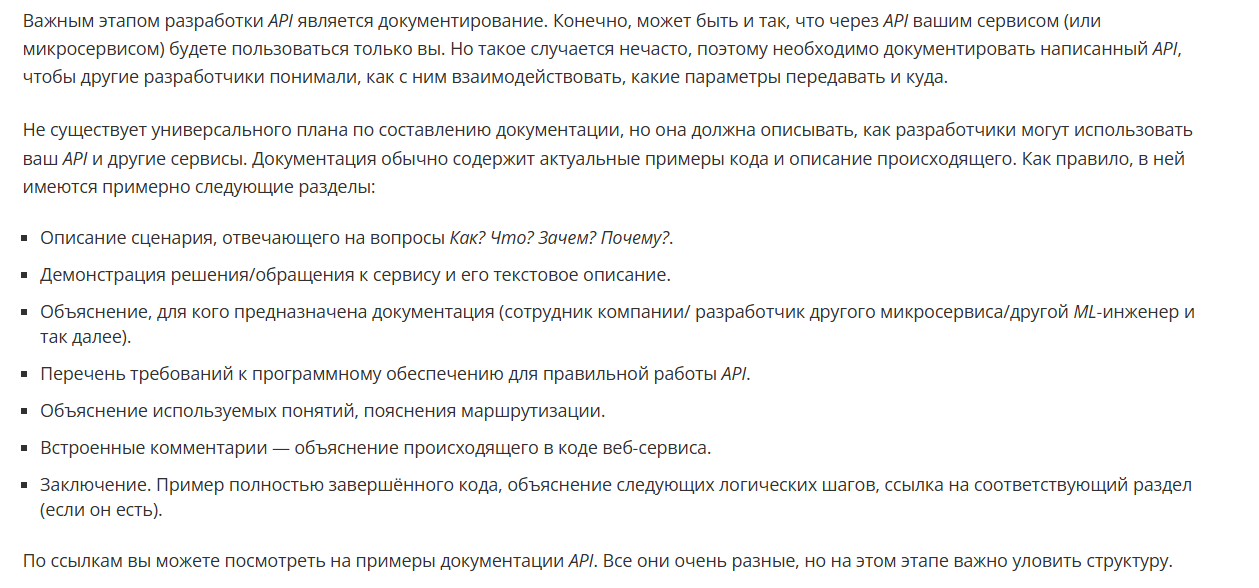

- Building a CI Server https://docs.github.com/en/rest/guides/building-a-ci-server?apiVersion=2026-03-10
- Introduction to Populating Website with API Data https://programminghistorian.org/en/lessons/introduction-to-populating-a-website-with-api-data
- Ebay Shopping API: Searching By Seller: Reviewing Information About A Seller https://developer.ebay.com/page-not-found
- Slack API: Actionable Notifications https://docs.slack.dev/404?from=%2Ftutorials%2Ftracks%2Factionable-notifications
- Facebook Pixel: Marketing API https://developers.facebook.com/documentation/meta-pixel/implementation/marketing-api

## Коды ответов

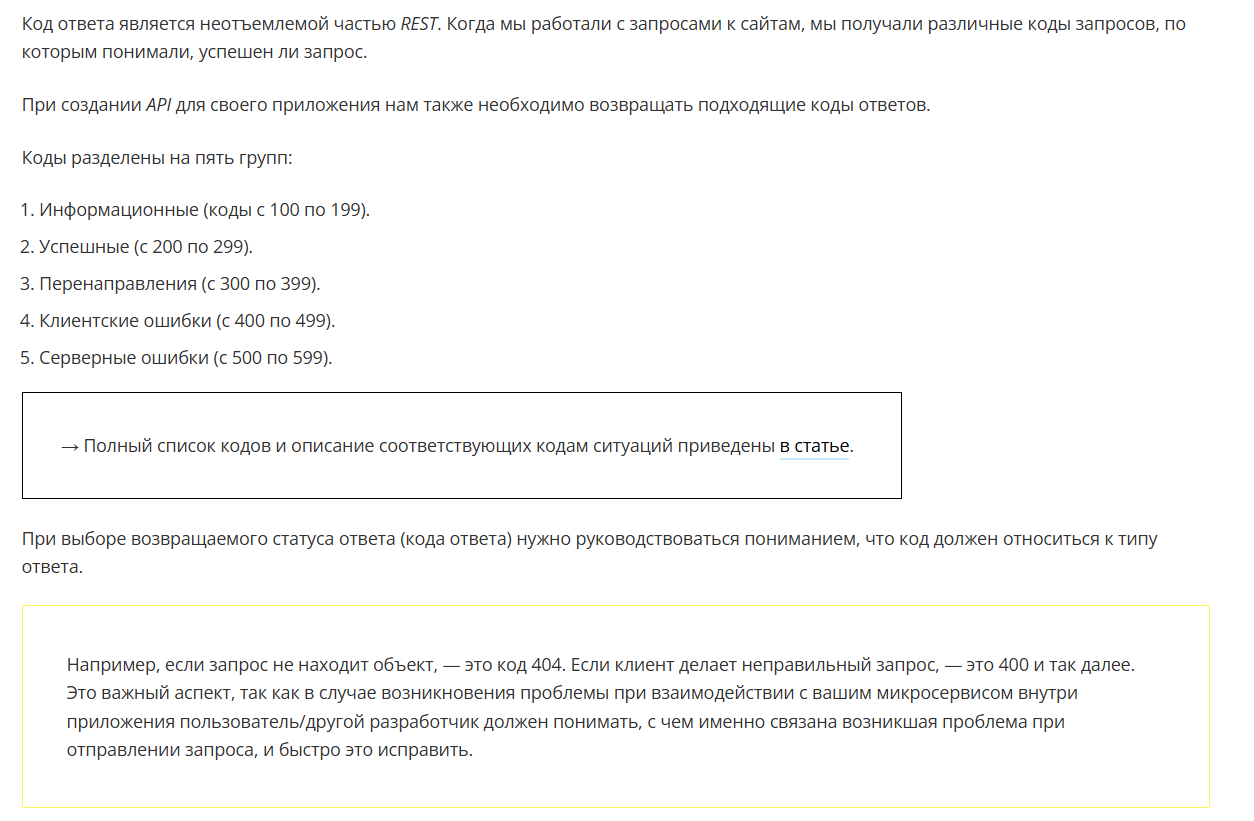

https://developer.mozilla.org/ru/docs/Web/HTTP/Status

# 6. Создание API веб-сервиса. Практика

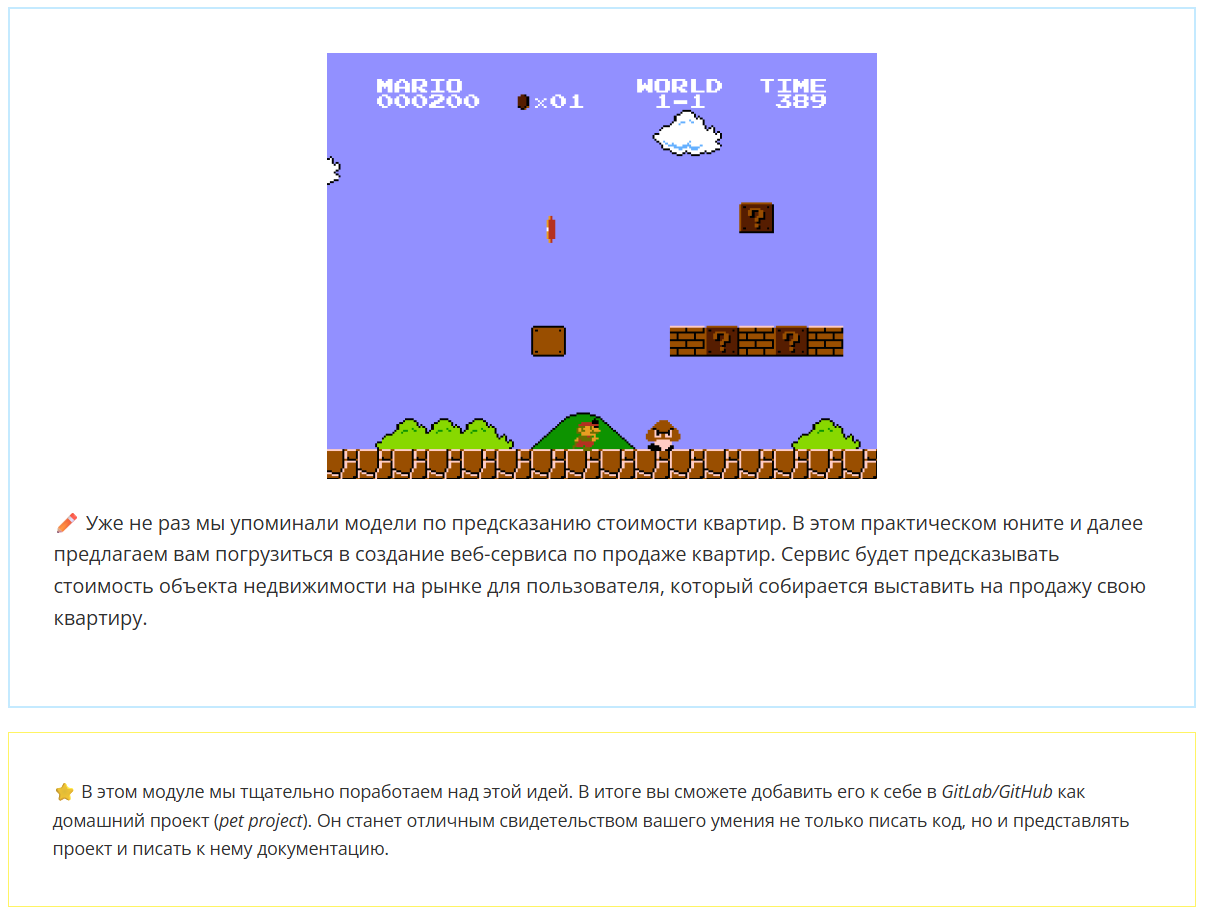

При разработке веб-приложения будем использовать подход REST для реализации серверной части приложения. На начальном этапе ограничимся браузером как платформой для реализации пользовательского интерфейса, а затем можно добавить приложения для смартфонов или настольные приложения для ПК с разными операционными системами. В этом практическом юните мы создадим API для нашего приложения. 

## Шаг 1. Функции

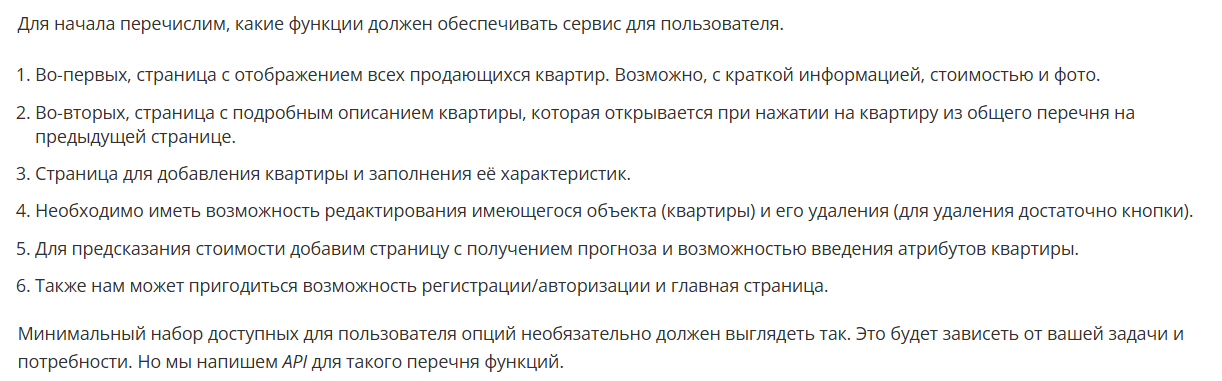

## Шаг 2. Маршрутизация

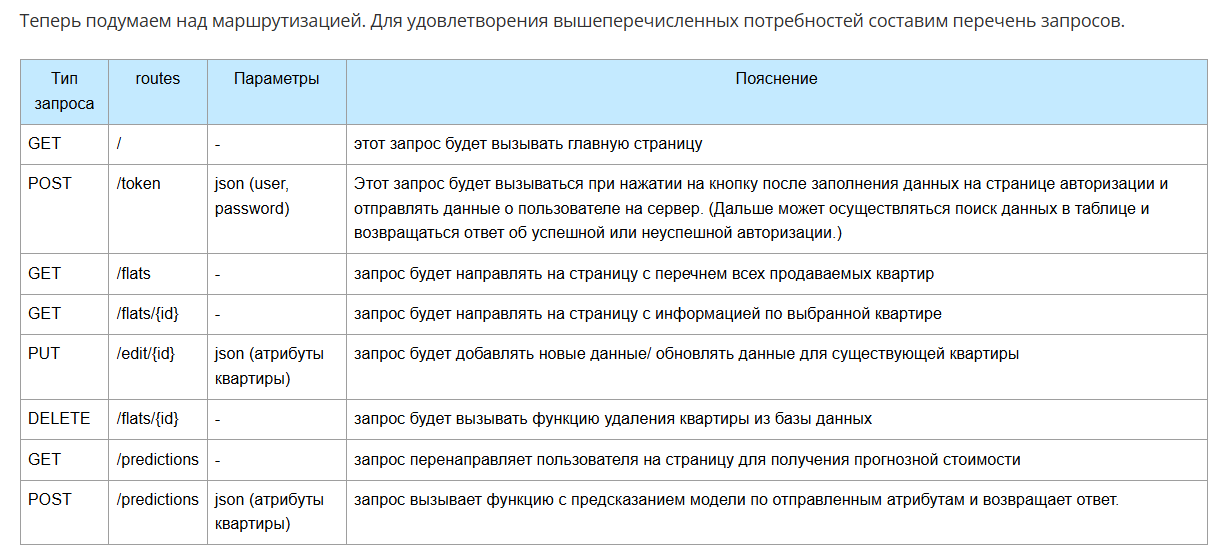

## шаг 3. Пример отправки запроса

Теперь добавим в документацию пример отправки запроса с параметрами.

Например, для авторизации было бы здорово, если бы при неправильных логине и пароле веб-сервис возвратил ошибку 401 (Unauthorized Error), а в случае нахождения пользователя и пароля в БД — код ошибки 200. Задокументируем этот пример.

В случае отсутствия пользователя с заданными параметрами:

In [ ]:
Request URL: http://{host:port}/token
parameters: {'user': 'admin', 'password':'12345'}

Response Body: 
{"error": 'invalid_grant'
"error_description":"Нет такого пользователя или неправильный пароль"
}

Response Code: 401

В случае существования пользователя с заданными параметрами:

In [ ]:
Request URL: http://{host:port}/token
parameters: {'user': 'admin', 'password':'admin'}

Response Body: 
{"success": true
}

Response Code: 200

Обратите внимание, что возвращать статусы запроса и обрабатывать параметры мы будем самостоятельно, поэтому названия ошибок, пояснения к ним и коды статуса запросов могут быть другими. Также в документации можно привести другие примеры.

Документацию в текстовом формате вы можете разместить как на отдельной странице своего веб-сервиса, так и добавить её в файл описания проекта.

⭐️ Мы описали API вручную, но для генерации документации можно пользоваться библиотекой Swashbuckle https://github.com/domaindrivendev/Swashbuckle.AspNetCore. После реализации веб-сервиса вы можете воспользоваться этой библиотекой и сравнить результаты.  

# 7. Создание веб-сервиса на Python

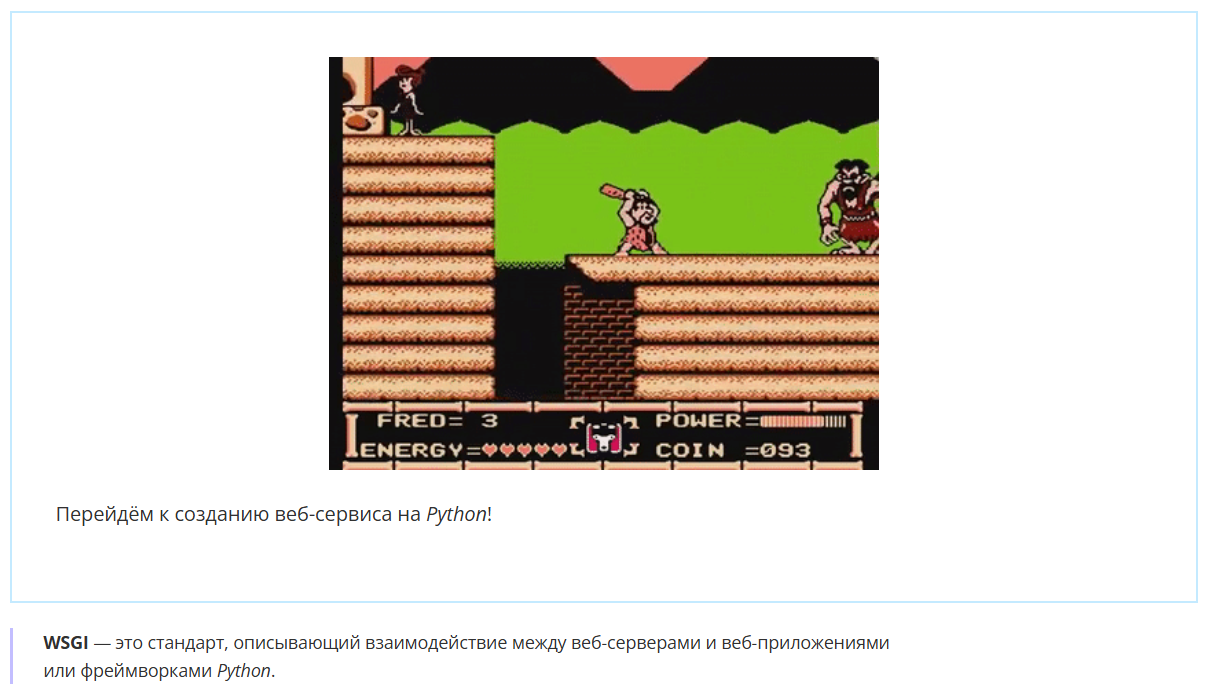

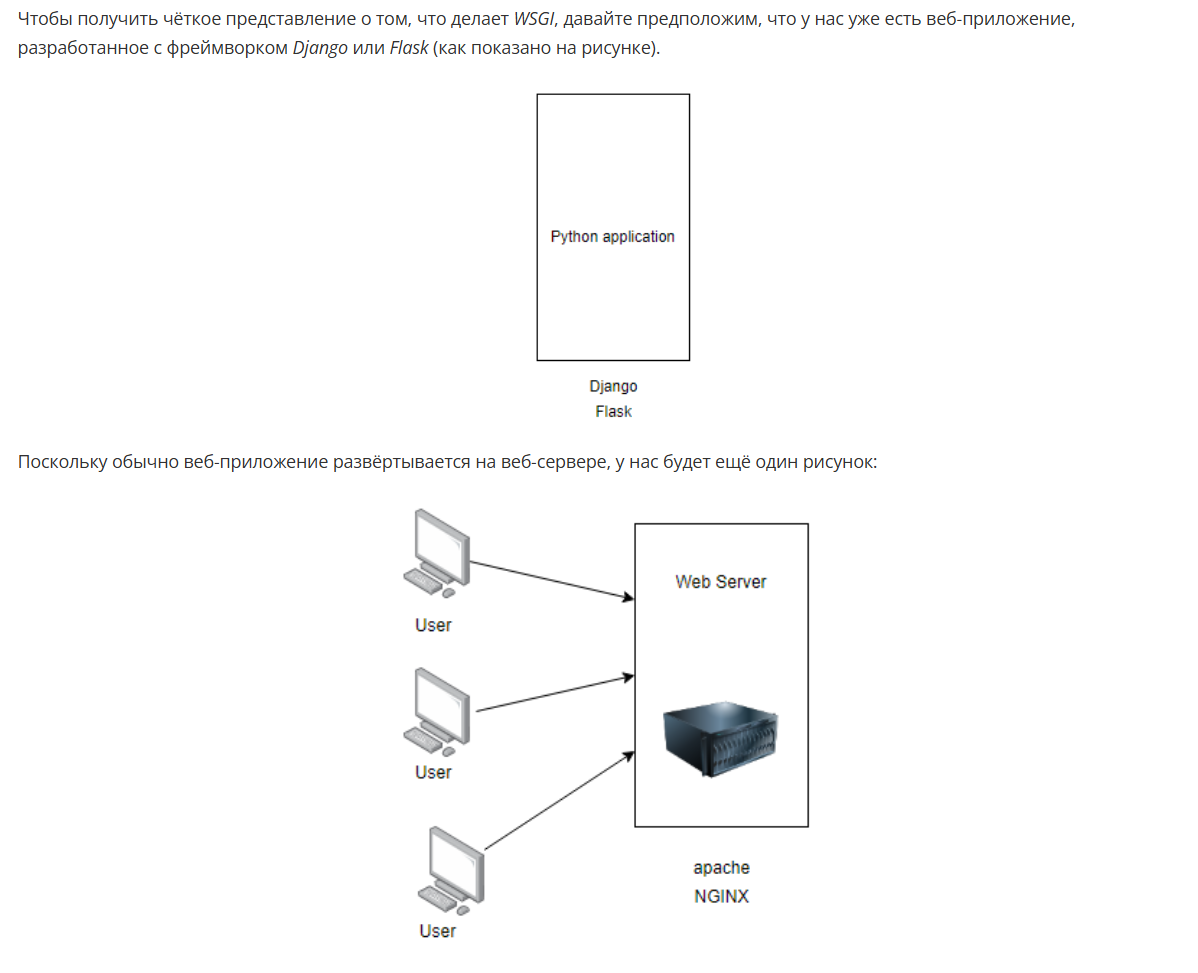

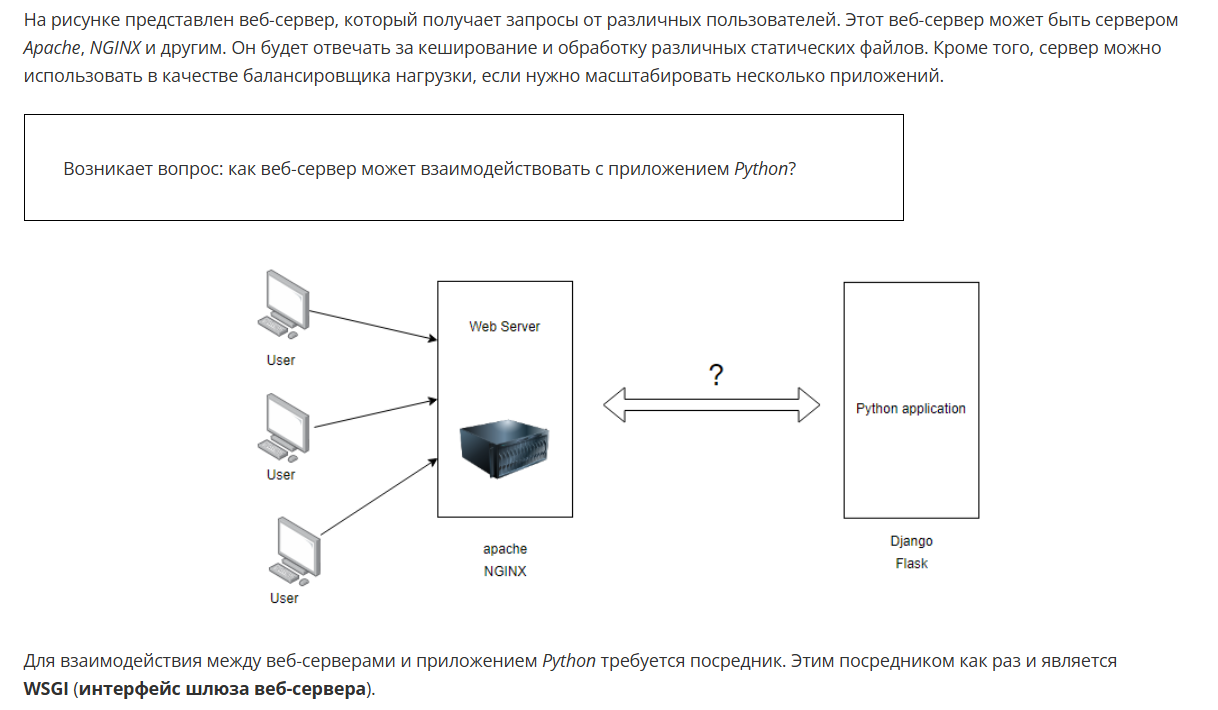

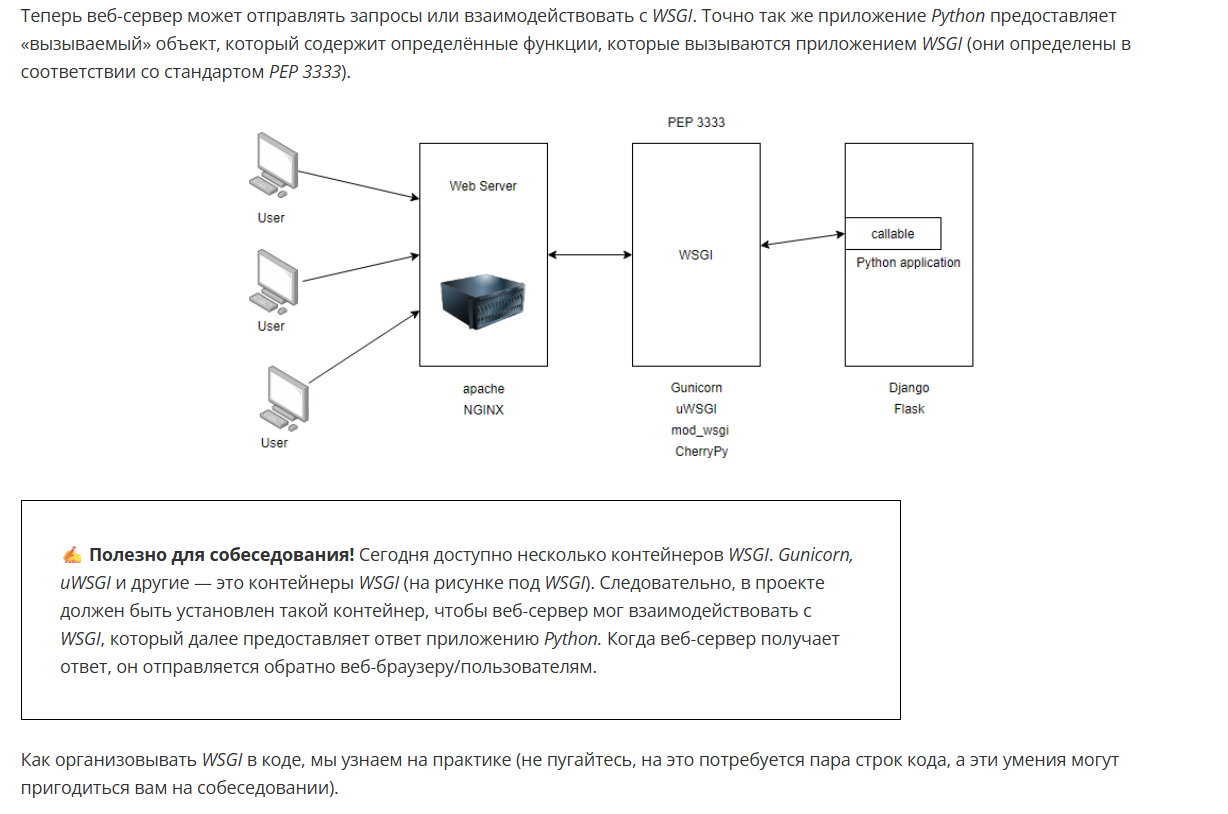

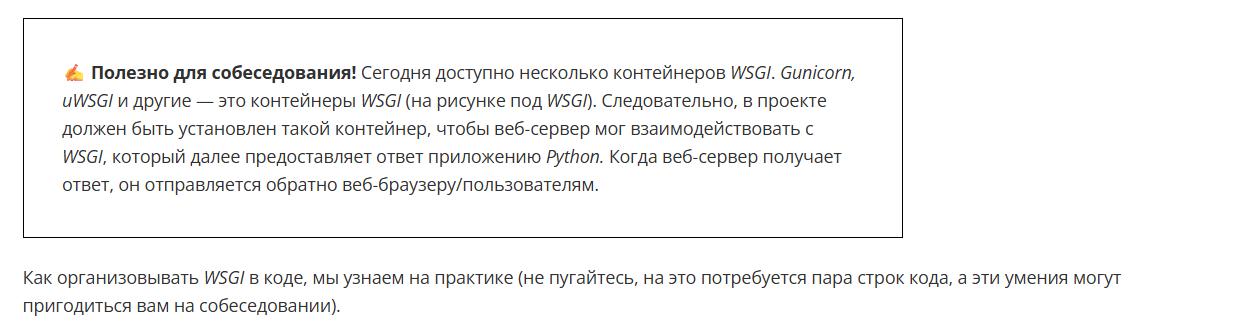

## Flask

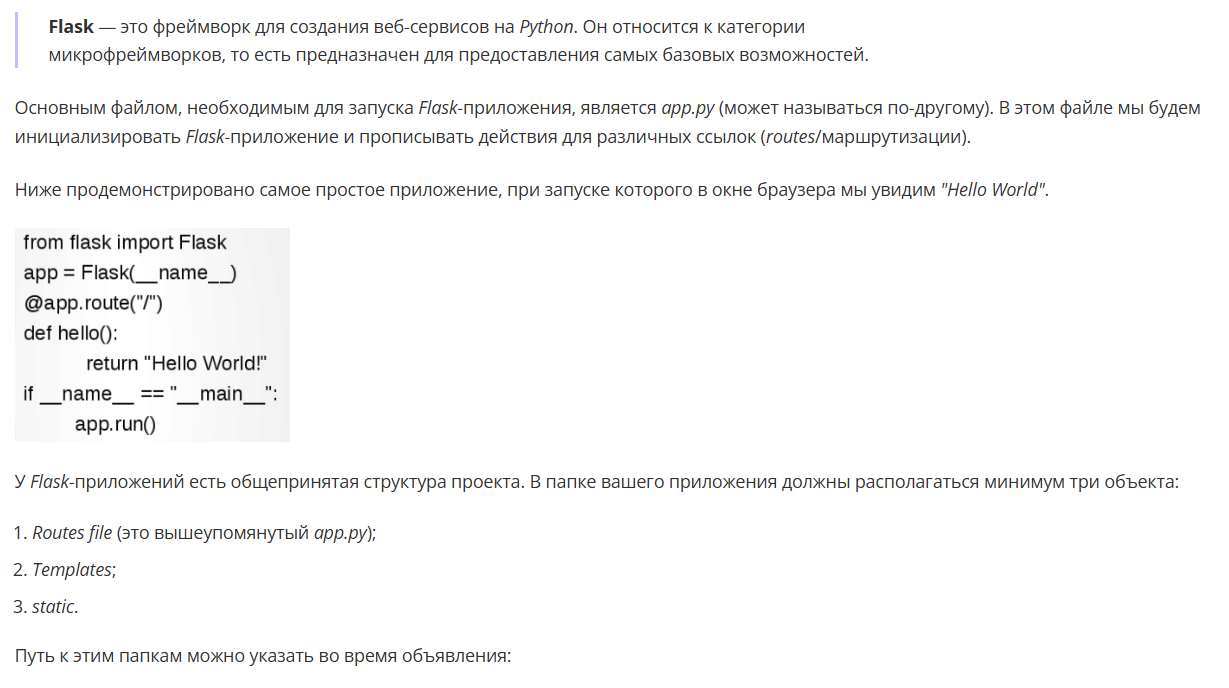

In [ ]:
app = Flask(__name__, 
static_url_path='', 
static_folder='web/static', 
template_folder='web/templates')

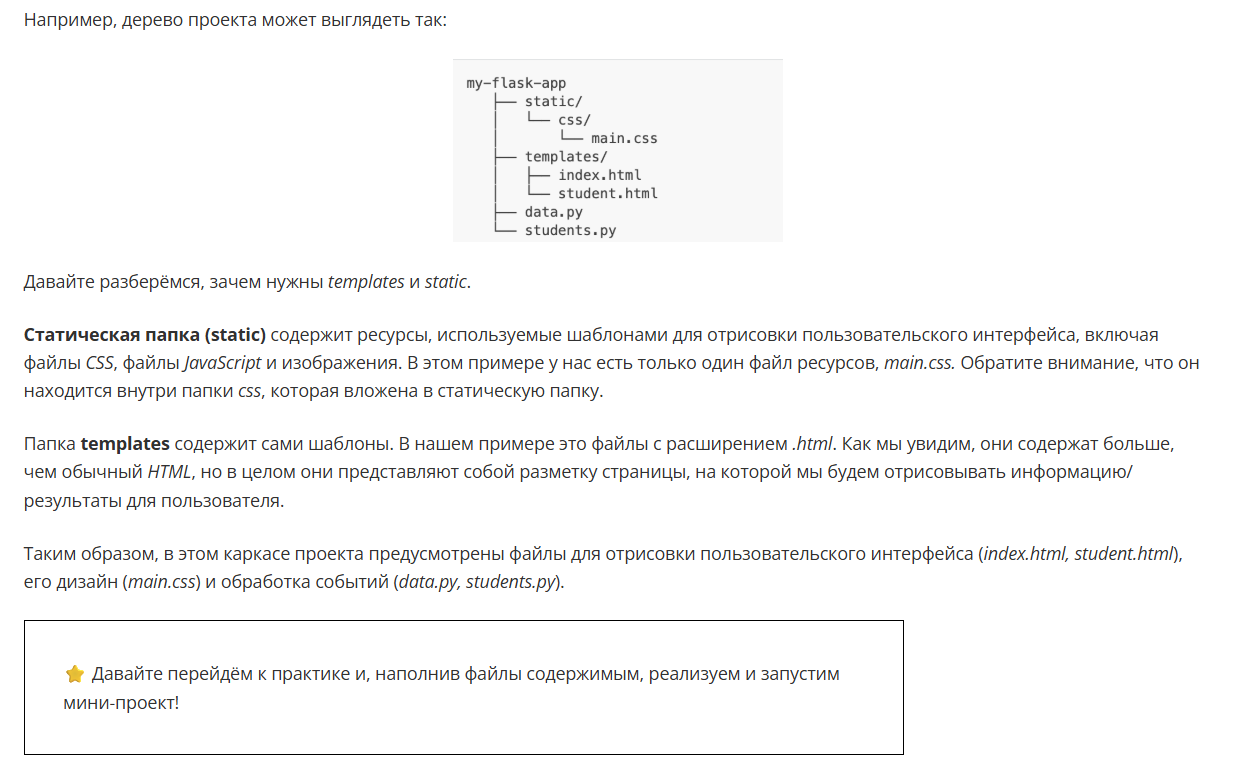

Дополнительные материалы

Официальная документация Flask https://flask.palletsprojects.com/en/stable/

Справочник по HTML https://htmlbook.ru/

Flask — WTF https://flask-wtf.readthedocs.io/en/1.0.x/

Flask SqlAlchemy https://flask-sqlalchemy.readthedocs.io/en/stable/

# 8. Создание веб-сервиса на Python. Практика

Предлагаем вам выполнить проект этого юнита в среде разработки **PyCharm**, бесплатную версию которой можно загрузить по ссылке https://www.jetbrains.com/ru-ru/pycharm/

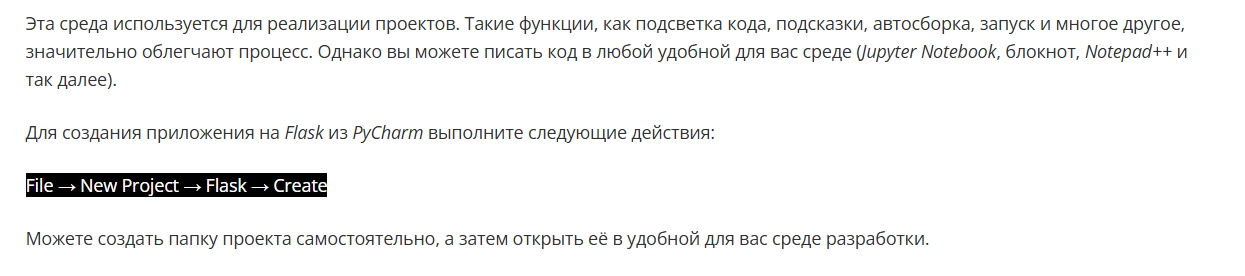

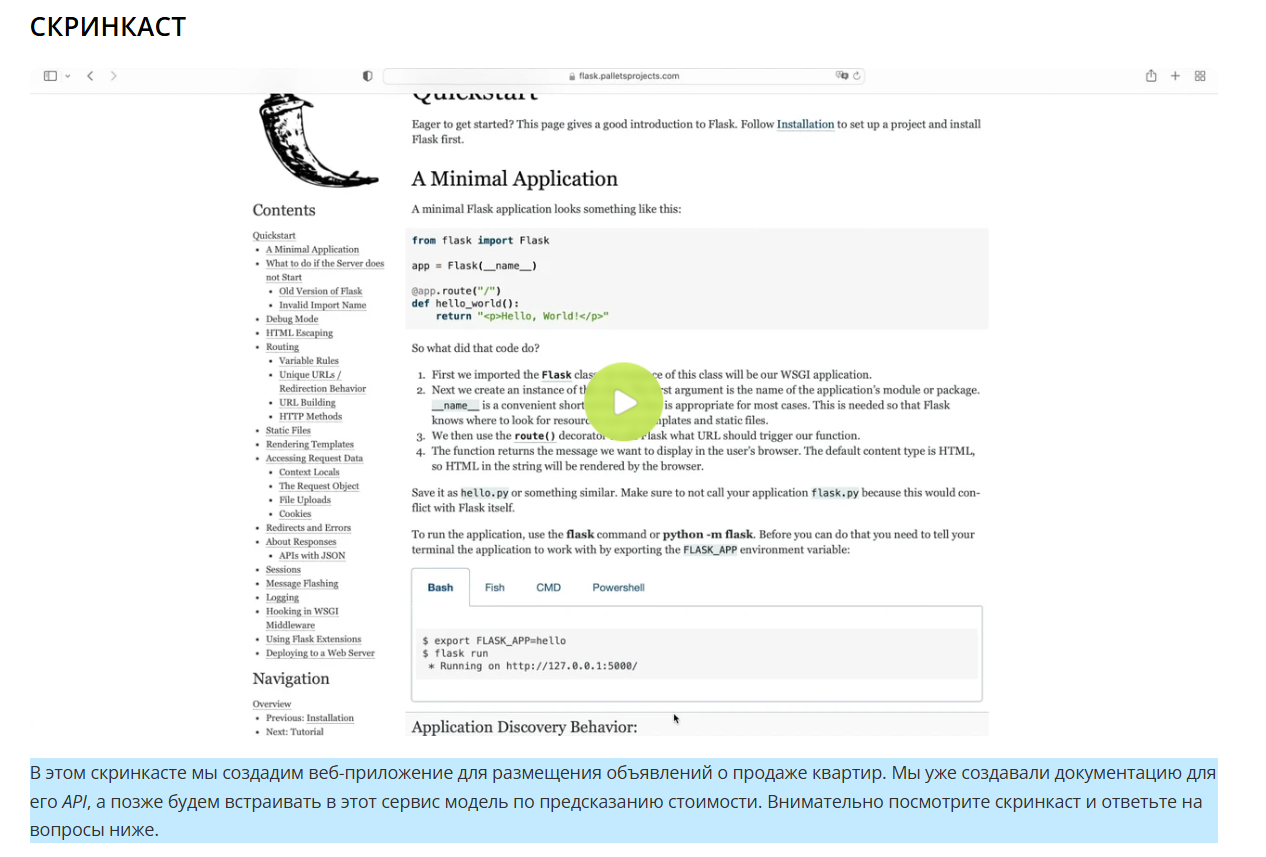

как:

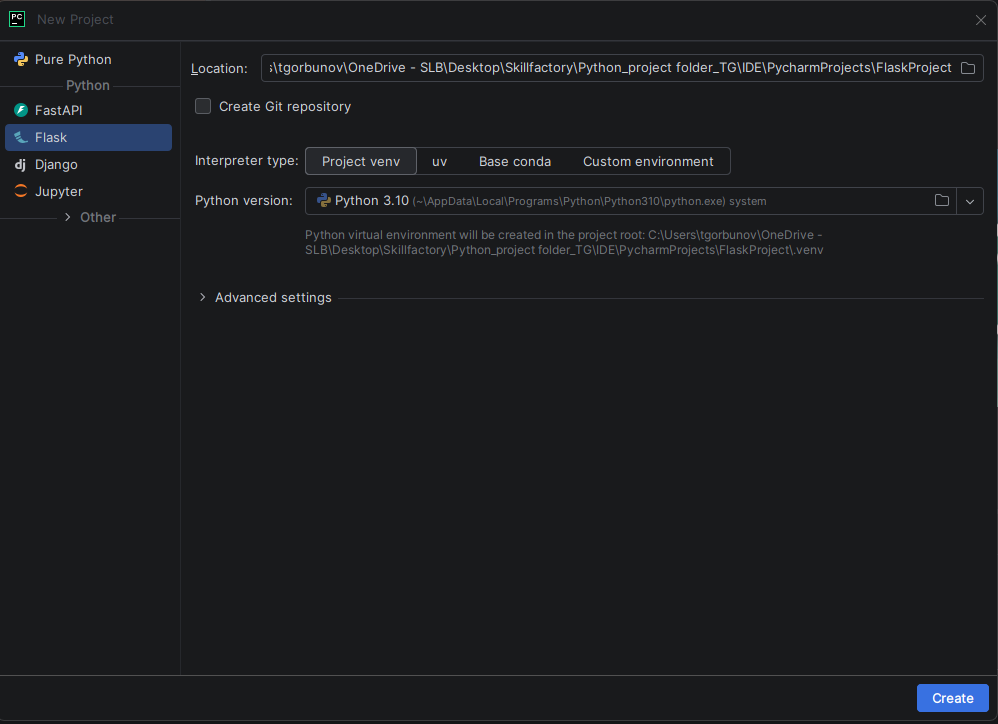

В этом скринкасте мы создадим веб-приложение для размещения объявлений о продаже квартир. Мы уже создавали документацию для его API, а позже будем встраивать в этот сервис модель по предсказанию стоимости. Внимательно посмотрите скринкаст и ответьте на вопросы ниже.

In [ ]:
#Команды из скринкаста
export FLASK_APP=houseapp.py

##Расширения flask:
###для создания и обработки форм 

pip install flask-wtf

###Для подключения базы данных

pip install flask-sqlalchemy
pip install flask-migrate

flask db init

# 9. Внедрение модели в веб-сервис

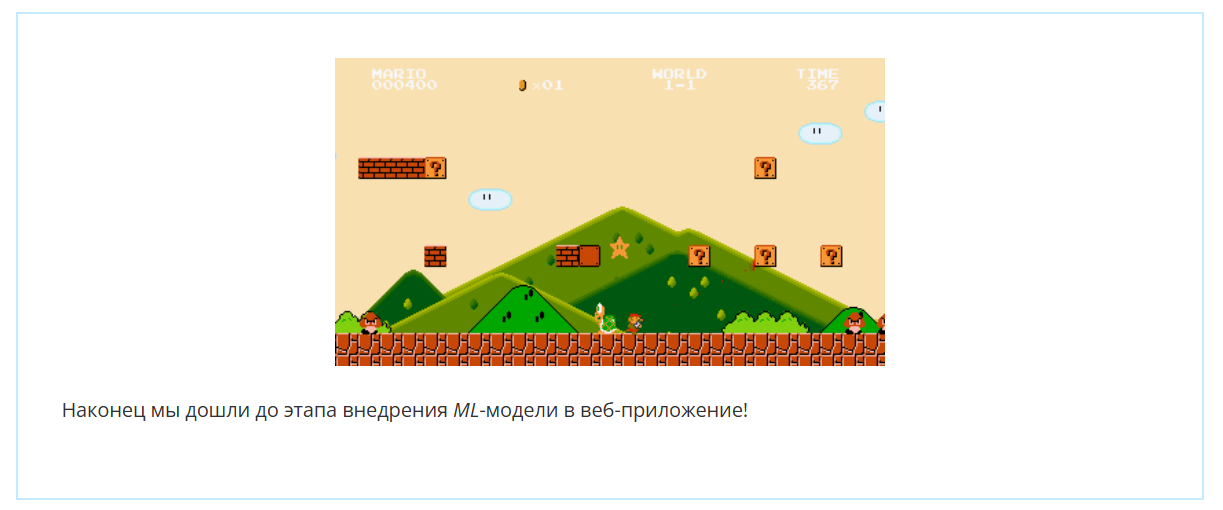

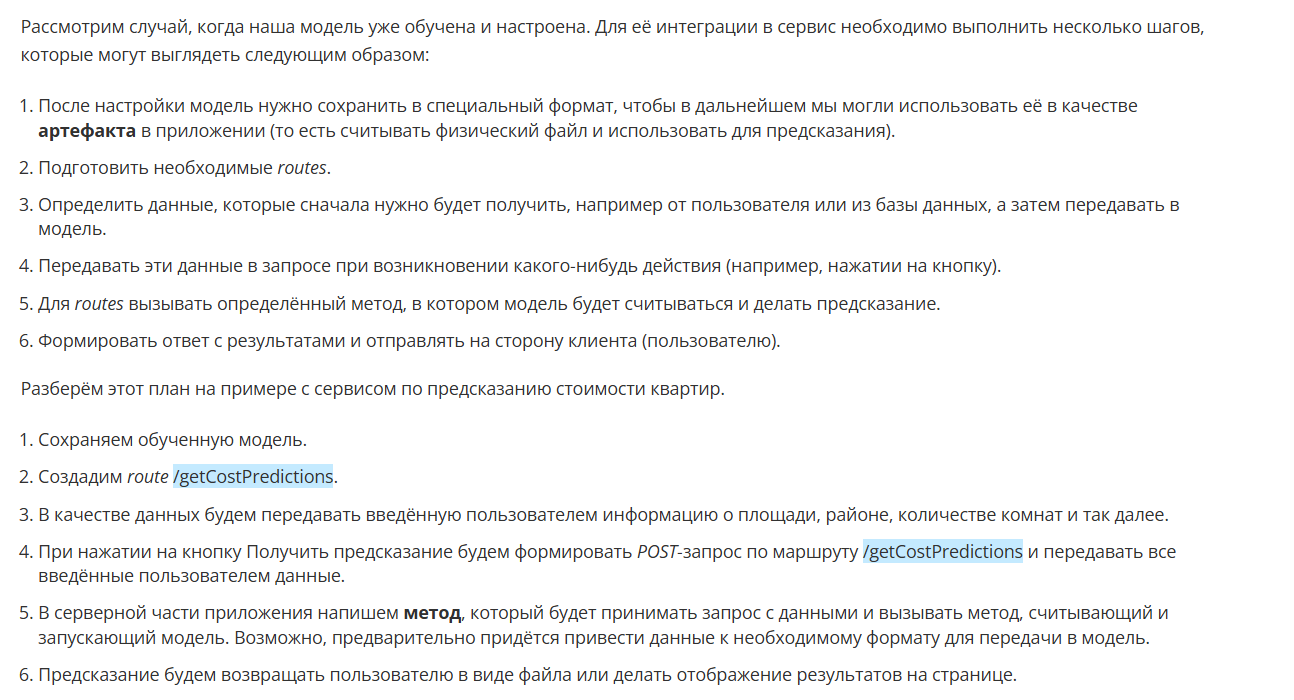

## Форматы сохранения модели

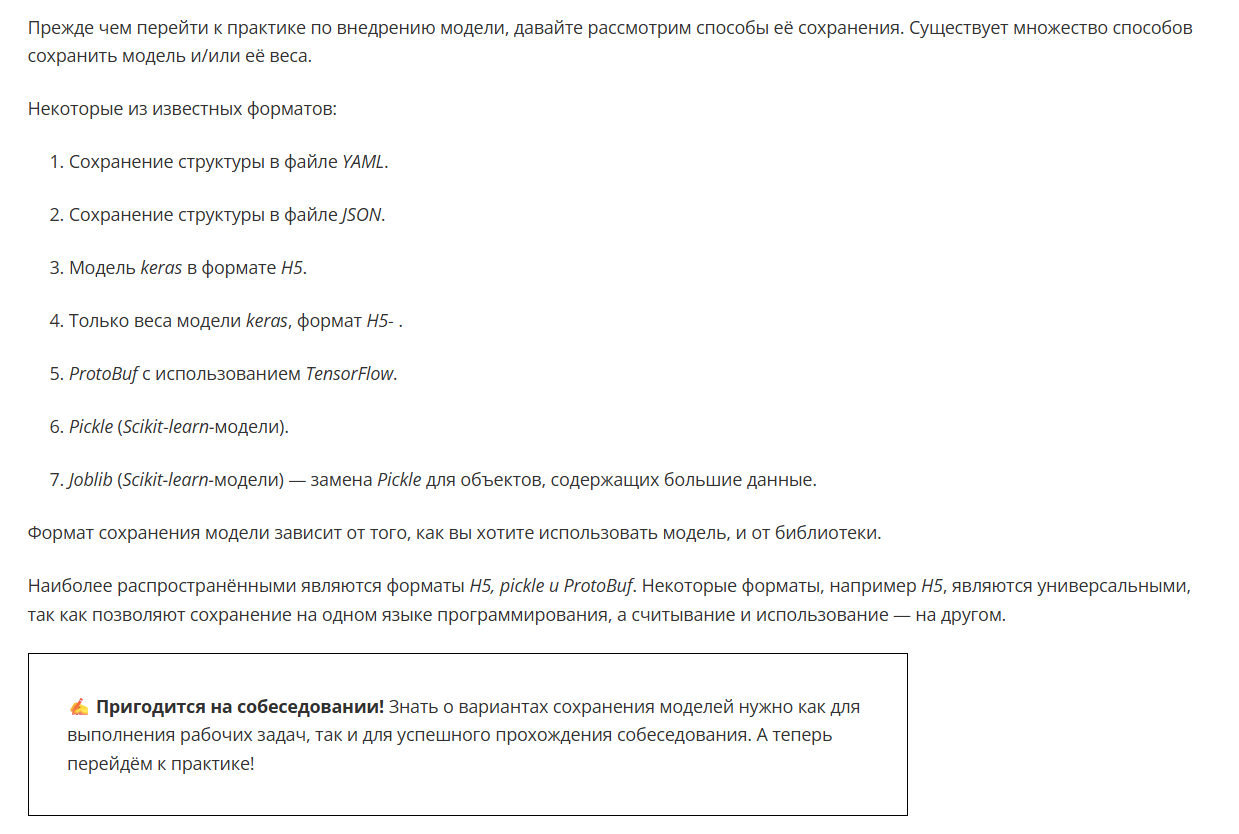

# 10. Внедрение модели в веб-сервис. Практика

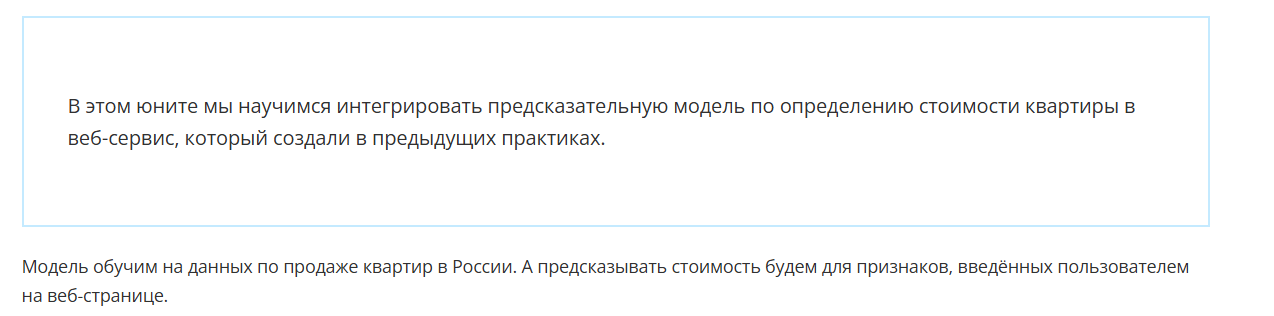

## Скринкаст

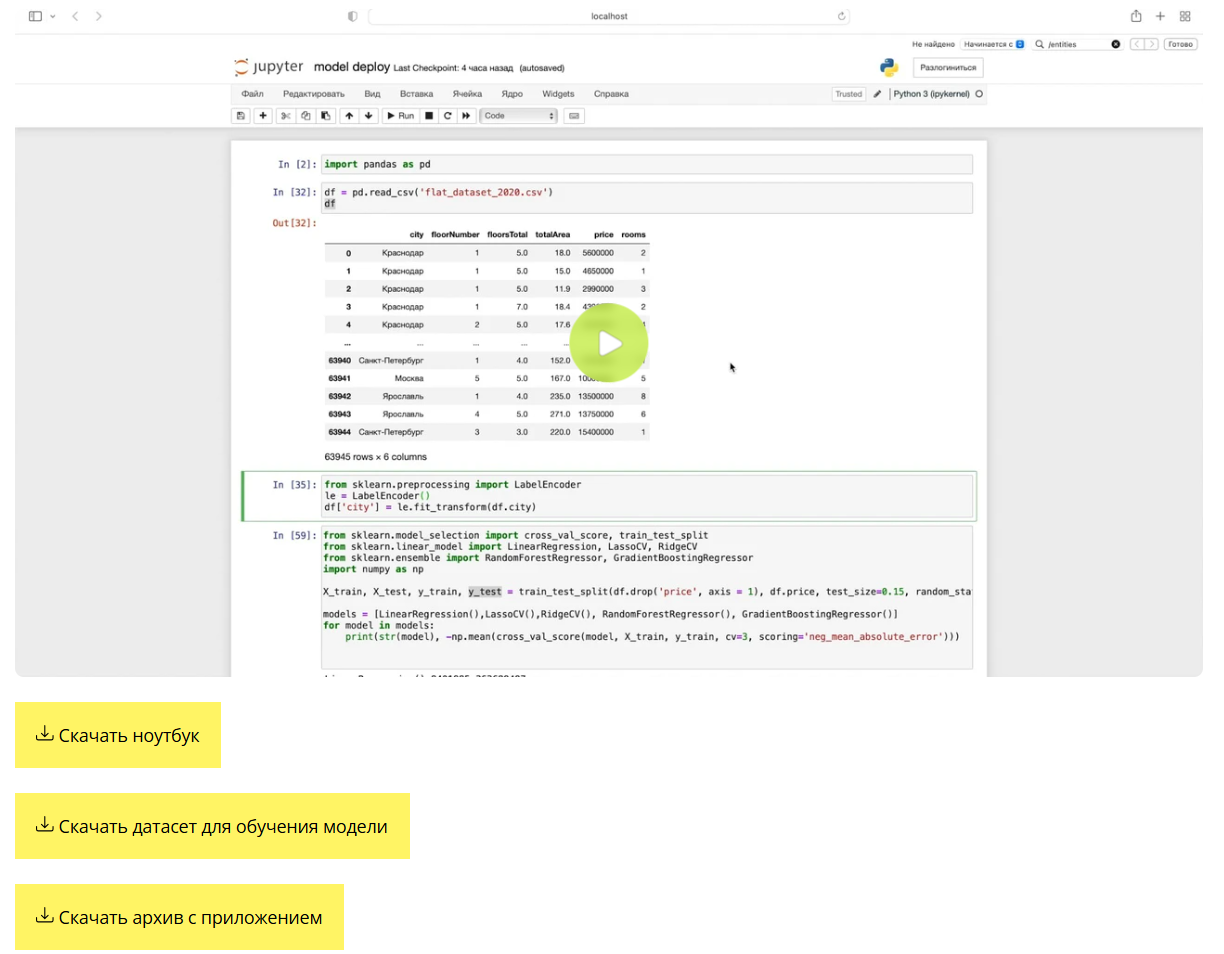

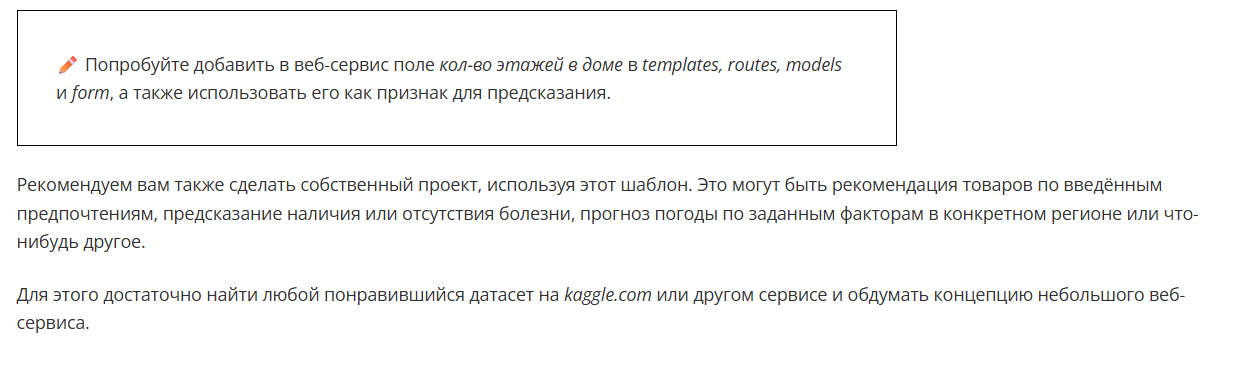

# 11. Проверка знаний

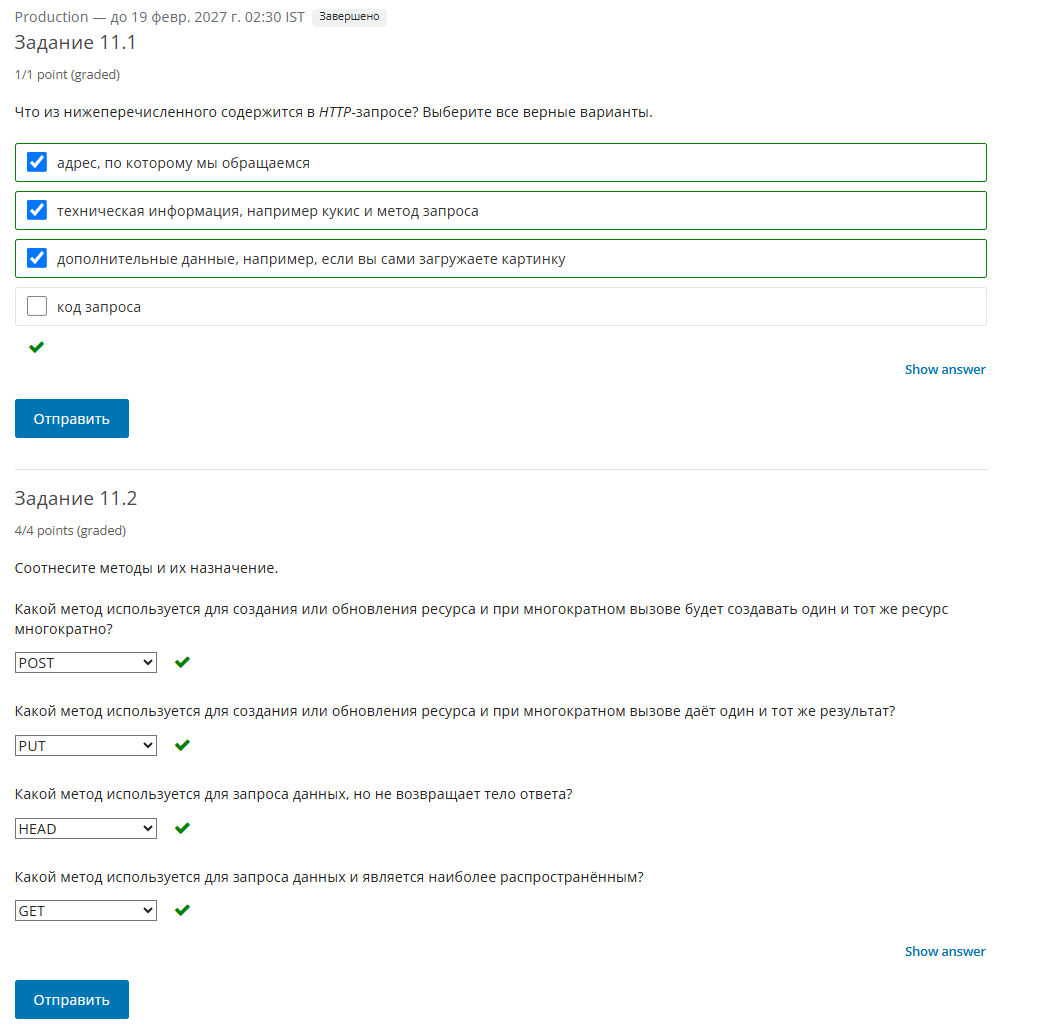

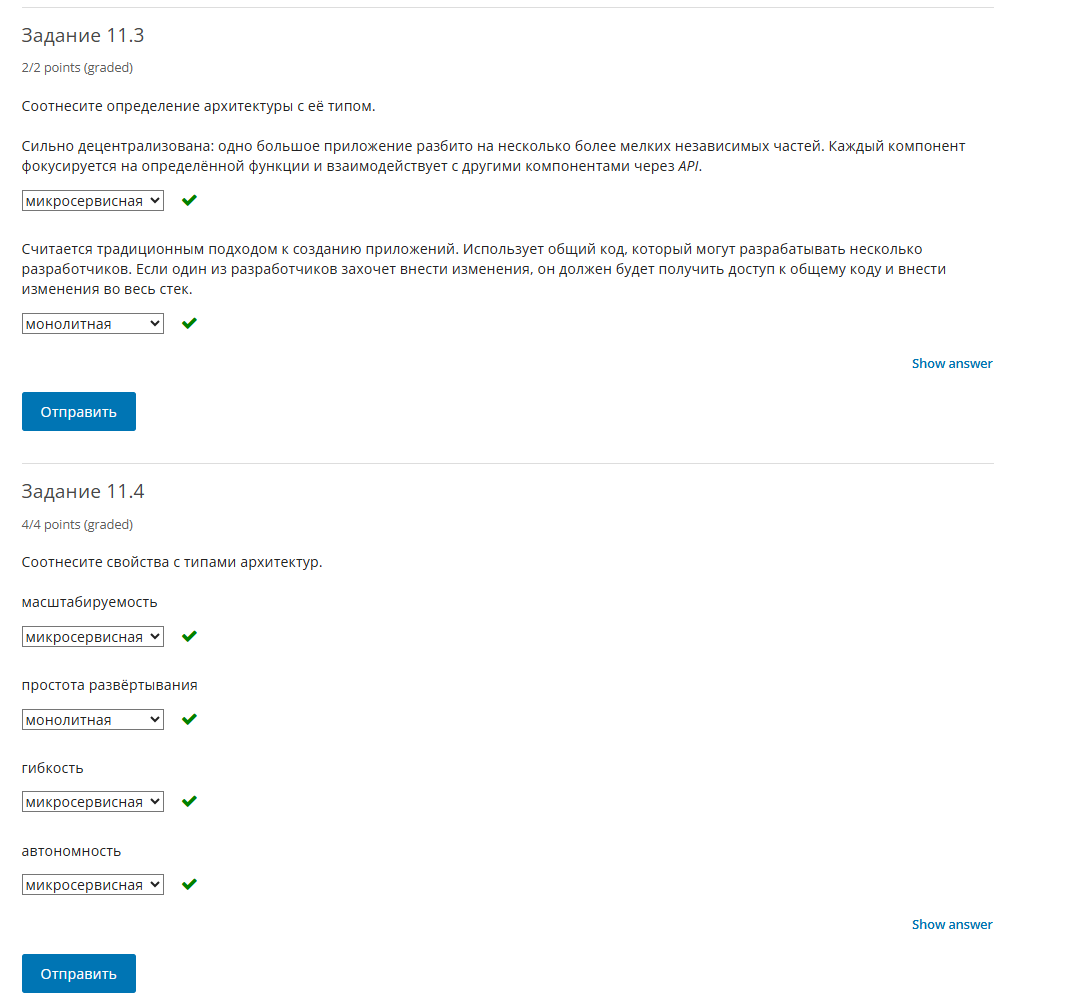

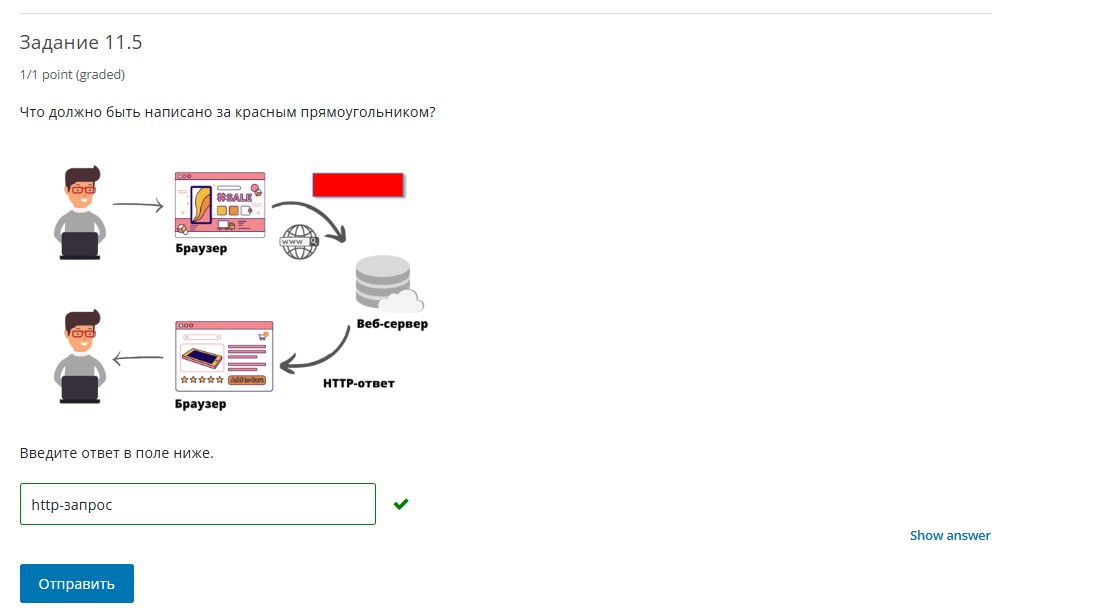

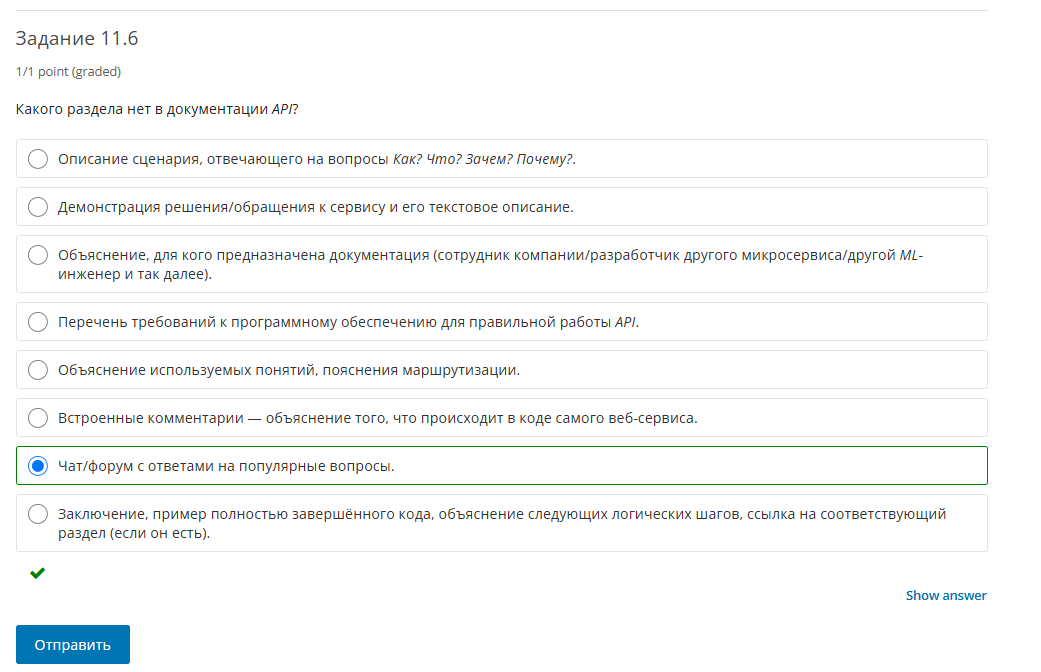

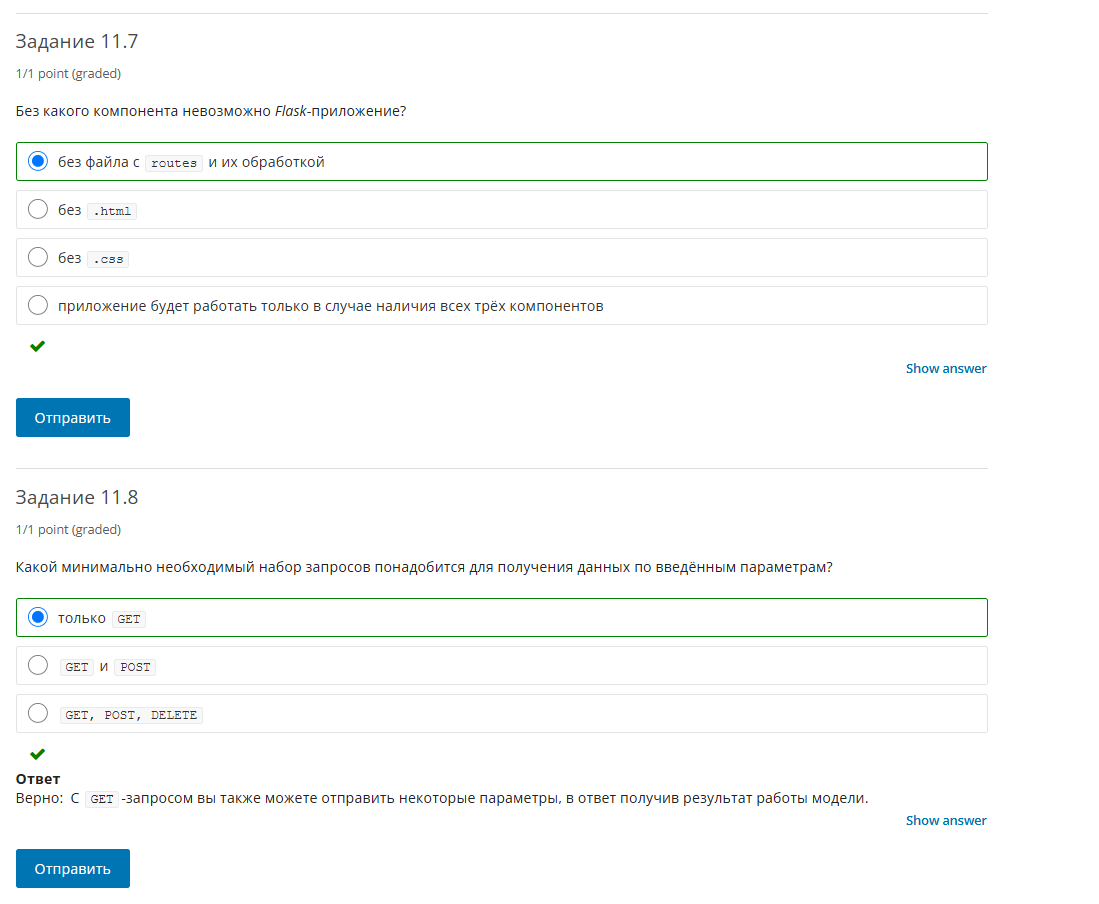

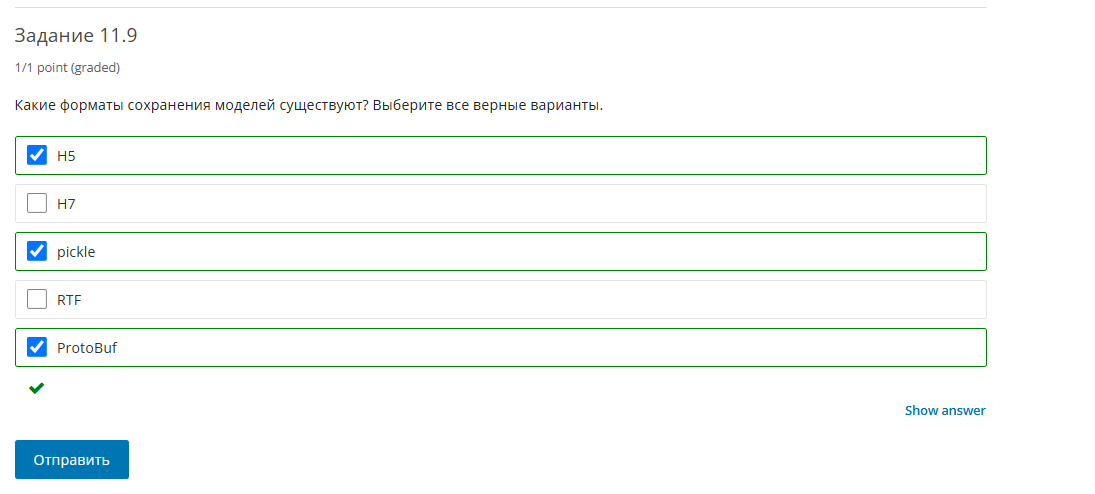

# 12. Подведём итоги

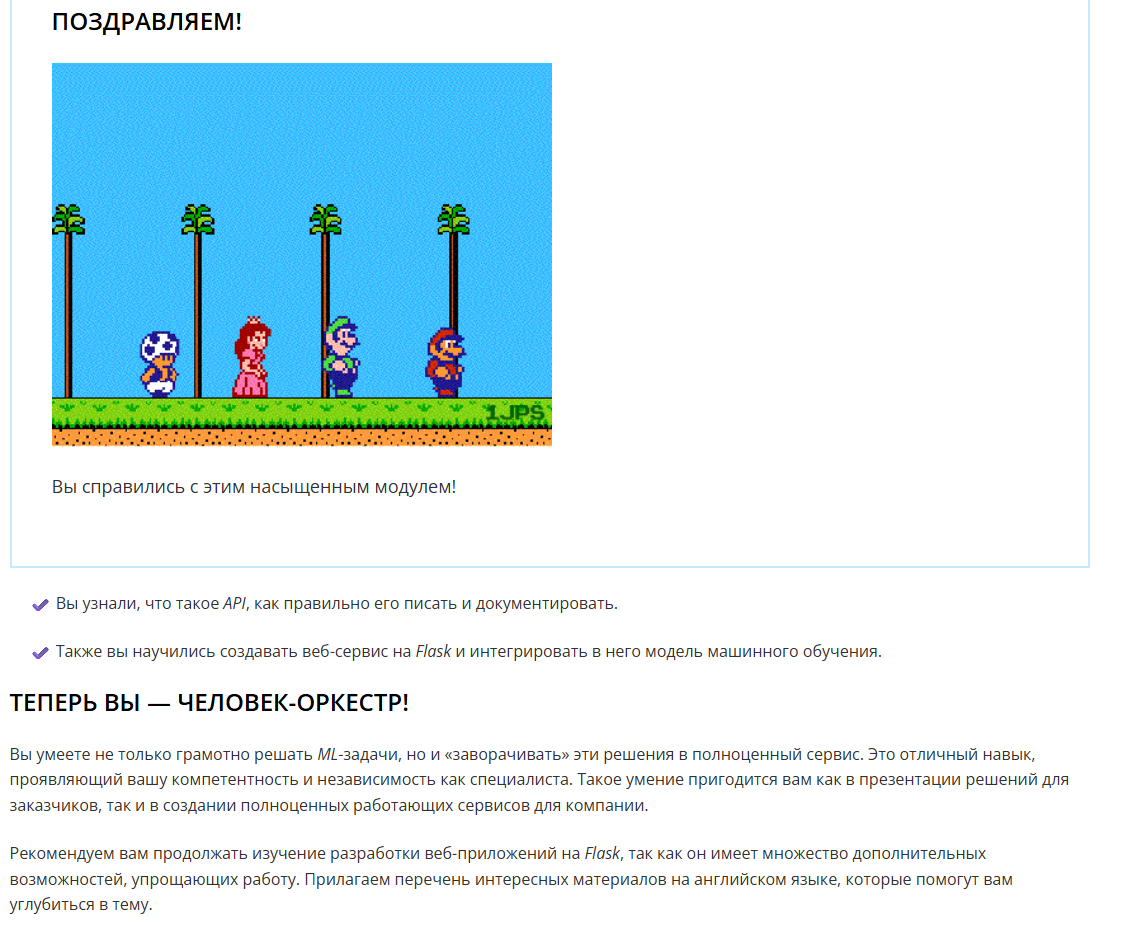

Дополнительные материалы:

Python Beginner Documentation https://python-adv-web-apps.readthedocs.io/en/latest/learn_python.html

Flask Advanced Functionality Documentation https://flask-admin.readthedocs.io/en/latest/advanced/

How to structure a Flask-RESTPlus web service for production builds https://www.freecodecamp.org/news/structuring-a-flask-restplus-web-service-for-production-builds-c2ec676de563

A Flask Full of Whiskey (WSGI) https://towardsdatascience.com/a-flask-full-of-whiskey-wsgi-e89525d6f9da/

Flask Tutorial https://realpython.com/tutorials/flask/